In [1]:
#Code for making Figure 1 

In [1]:
#Importing Important Stuff
import fmEphys as fme
import os, json
import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp
import scipy.ndimage
import scipy.interpolate
from tqdm import tqdm
from glob import glob
import os
import matplotlib 
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import pyplot as plt
from matplotlib import transforms
import sklearn.neighbors
import sklearn.linear_model
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from scipy.ndimage import gaussian_filter1d 
import math
from datetime import datetime


Loading DLC 2.3.0...


In [2]:

def jitter(c, sz, maxdist=0.25):
    """ Jitter x values.

    This is useful for scatter plots of categorical data,
    when the distribution along y is more clear when the
    x position of that category is jittered slightly.

    Parameters
    ----------
    c : int or float
        Center position of the data.
    sz : int
        Number of data points.
    maxdist : float
        Maximum distance that a value can be jittered
        from their center point, `c`.

    Returns
    -------
    j_x : np.array
        Jittered x values in a 1D array of length `sz`.

    """

    j_x = np.ones(sz) + np.random.uniform(c-maxdist, c+maxdist, sz)

    return j_x
    
def interpNan(x,r):
    ## Linear interpolate across strings of NaNs smaller or equal to length r
    ## leaves NaNs at start and end to prevent extrapolation
    ## x= Data array
    ## r = max allowed string of NaNs to interpolate over
   
    ## written by RJS 7/13/24 
    ## converted from Niell Lab interpNan.m function 

    xtemp = np.where(~np.isnan(x)==1)[0]
    ytemp = x[~np.isnan(x)]
    
    #Initial Interpolation
    y = scipy.interpolate.interp1d(xtemp,ytemp,kind='linear',bounds_error=False)(np.arange(0,len(x),1))

    #Finding NaN Strings
    bad = (np.isnan(x)*1)

    #Finding Onset of NaN Strings
    starts = np.where(np.diff(bad)>0)
    starts = starts[0]
    starts = starts+1

    #Finding Offsets of NaN Strings
    ends = np.where(np.diff(bad)<0)
    ends = ends[0]

    #If the first data point is NaN then it causes problems with np.diff(bad), such that ends become starts and starts become ends. 
    if bad[0] == 1:
        ends = ends[1:]


    #Looping Through NaN Strings to Find ones shorter than r
    for ii in range(0,len(ends)):
        #If string(ii) is shorter than r and NaN string isnt the first piece of data (to avoid extrapolation)
        if (((ends[ii]-starts[ii])+1 <= r) and (starts[ii]!=0)):
            #Then convert that string from 1 to 0
            bad[starts[ii]:ends[ii]+1] = bad[starts[ii]:ends[ii]+1]*0


    #replacing any NaN string larger than r or at the begining/end of data 
    y[bad == 1] = np.nan
    
    return y

def open_dlc_h5(dlc_path, h5key=None):
    """ Open the .h5 file generated by DLC.

    Parameters
    ----------
    h5key : str
        The key to the .h5 file. Default is None.

    """
    
    if h5key is None:
        # read the .hf file when there is no key
        pts = pd.read_hdf(dlc_path)
    
    else:
        # read in .h5 file when there is a key set in corral_files.py
        pts = pd.read_hdf(dlc_path, key=h5key)
    
    # organize columns
    pts.columns = [' '.join(col[:][1:3]).strip() for col in pts.columns.values]
    
    pts = pts.rename(columns={pts.columns[n]: pts.columns[n].replace(' ', '_') for n in range(len(pts.columns))})
    pt_loc_names = pts.columns.values
    return pts, pt_loc_names


#These are functions that i copied from our data analysis pipeline, I can explain them in person

def read_timestamp_series(s):
    """ Read timestamps as a pd.Series and format time.

    Parameters
    ----------
    s : pd.Series
        Timestamps as a Series. Expected to be formated as
        hours:minutes:seconds.microsecond

    Returns
    -------
    output_time : np.array
        Returned as the number of seconds that have passed since the
        previous midnight, with microescond precision, e.g. 700.000000

    """

    # Expected string format for timestamps.
    fmt = '%H:%M:%S.%f'

    output_time = []

    if s.dtype != np.float64:

        for current_time in s:

            str_time = str(current_time).strip()

            try:
                t = datetime.strptime(str_time, fmt)

            except ValueError as v:
                # If the string had unexpected characters (too much precision) for
                # one timepoint, drop the extra characters.

                ulr = len(v.args[0].partition('unconverted data remains: ')[2])
                
                if ulr:
                    str_time = str_time[:-ulr]
            
            try:
                output_time.append(
                        (datetime.strptime(str_time, '%H:%M:%S.%f')
                            - datetime.strptime('00:00:00.000000', '%H:%M:%S.%f')
                            ).total_seconds())

            except ValueError:
                output_time.append(np.nan)

        output_time = np.array(output_time)

    else:
        output_time = s.values

    return output_time

##################################################

def interp_timestamps(camT, use_medstep=False):
    """ Interpolate timestamps for double the number of
    frames. Compensates for video deinterlacing.
    
    Parameters
    ----------
    camT : np.array
        Camera timestamps aquired at 30Hz
    use_medstep : bool
        When True, the median diff(camT) will be used as the timestep
        in interpolation. If False, the timestep between each frame
        will be used instead.

    Returns
    -------
    camT_out : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array. Each timestamp in camT will
        be replaced by two, set equal distances from the original.

    """

    camT_out = np.zeros(np.size(camT, 0)*2)
    medstep = np.nanmedian(np.diff(camT, axis=0))

    if use_medstep:
        
        # Shift each deinterlaced frame by 0.5 frame periods
        # forward/backwards assuming a constant framerate

        camT_out[::2] = camT - 0.25 * medstep
        camT_out[1::2] = camT + 0.25 * medstep
    
    elif not use_medstep:

        # Shift each deinterlaced frame by the actual time between
        # frames. If a camera frame was dropped, this approach will
        # be more accurate than `medstep` above.
        
        steps = np.diff(camT, axis=0, append=camT[-1]+medstep)
        camT_out[::2] = camT
        camT_out[1::2] = camT + 0.5 * steps

    return camT_out

##################################################

def read_timestamp_file(file_loc, position_data_length=None,
                        force_timestamp_shift=False):
    """ Read timestamps from a .csv file.

    Parameters
    ----------
    position_data_length : None or int
        Number of timesteps in data from deeplabcut. This is used to
        determine whether or not the number of timestamps is too short
        for the number of video frames.
        Eyecam and Worldcam will have half the number of timestamps as
        the number of frames, since they are aquired as an interlaced
        video and deinterlaced in analysis. To fix this, timestamps need
        to be interpolated.
    force_timestamp_shift : bool
        When True, the timestamps will be interpolated regardless of
        whether or not the number of timestamps is too short for the
        number of frames. Default is False.

    Returns
    -------
    camT : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array than there were in the provided
        csv file.

    """

    # Read data and set up format
    s = pd.read_csv(file_loc, encoding='utf-8',
                    engine='c', header=None).squeeze()
    
    # If the csv file has a header name for the column, (which is
    # is the int 0 for some early recordings), remove it.
    if s[0] == 0:
        s = s[1:]
    
    # Read the timestamps as a series and format them
    camT = read_timestamp_series(s)
    
    # Auto check if vids were deinterlaced
    if position_data_length is not None:

        if position_data_length > len(camT):

            # If the number of timestamps is too short for the number
            # of frames, interpolate the timestamps.

            camT = interp_timestamps(camT, use_medstep=False)
    
    # Force the times to be shifted if the user is sure it should be done
    if force_timestamp_shift is True:

        camT = interp_timestamps(camT, use_medstep=False)
    
    return camT

def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=1)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.25)
    #plt.legend()


def drop_repeat_events(eventT, onset=True, win=0.020):
    """Eliminate saccades repeated over sequential camera frames.

    Saccades sometimes span sequential camera frames, so that two or
    three sequential camera frames are labaled as saccade events, despite
    only being a single eye/head movement. This function keeps only a
    single frame from the sequence, either the first or last in the
    sequence.

    Parameters
    ----------
    eventT : np.array
        Array of saccade times (in seconds as float).
    onset : bool
        If True, a sequence of back-to-back frames labeled as a saccade will
        be reduced to only the first/onset frame in the sequence. If false, the
        last in the sequence will be used.
    win : float
        Distance in time (in seconds) that frames must follow each other to be
        considered repeating. Frames are 0.016 ms, so the default value, 0.020
        requires that frames directly follow one another.

    Returns
    -------
    thinned : np.array
        Array of saccade times, with repeated labels for single events removed.

    """

    duplicates = set([])
    for t in eventT:
        if onset:
            # keep first
            new = eventT[((eventT-t)<win) & ((eventT-t)>0)]
        else:
            # keep last
            new = eventT[((t-eventT)<win) & ((t-eventT)>0)]
        duplicates.update(list(new))

    thinned = np.sort(np.setdiff1d(eventT,
                                   np.array(list(duplicates)),
                                   assume_unique=True))
    
    return thinned


In [5]:
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'F:\Science\Freely Moving Ephys\DOI Mice\101724\G6CK10JRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\052124\J691RT',
                   r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']

#Saline_RecordingsToUse = []

In [5]:
RecordingsToUse = [r'D:\080224\J705RT']

In [6]:
Plt_IndMice = 0 #set to 1 to plot individual mice data and 0  to skip 

Pre_GazePerMin = np.zeros(len(RecordingsToUse))
Post_GazePerMin = np.zeros(len(RecordingsToUse))

Pre_CompPerMin = np.zeros(len(RecordingsToUse))
Post_CompPerMin = np.zeros(len(RecordingsToUse))

Pre_GazePerMin_new = np.zeros(len(RecordingsToUse))
Post_GazePerMin_new = np.zeros(len(RecordingsToUse))

Pre_CompPerMin_new = np.zeros(len(RecordingsToUse))
Post_CompPerMin_new = np.zeros(len(RecordingsToUse))
  
PreDOI_theta_gazeL = np.ones((1,120))*np.nan
PreDOI_pYaw_gazeL = np.ones((1,120))*np.nan
PreDOI_pGaze_gazeL = np.ones((1,120))*np.nan
PreDOI_dEye_gazeL = np.ones((1,120))*np.nan
PreDOI_dHead_gazeL = np.ones((1,120))*np.nan
PreDOI_dGaze_gazeL = np.ones((1,120))*np.nan
PreDOI_pupilsize_gazeL = np.ones((1,120))*np.nan

PreDOI_theta_gazeR = np.ones((1,120))*np.nan
PreDOI_pYaw_gazeR = np.ones((1,120))*np.nan
PreDOI_pGaze_gazeR = np.ones((1,120))*np.nan
PreDOI_dEye_gazeR = np.ones((1,120))*np.nan
PreDOI_dHead_gazeR = np.ones((1,120))*np.nan
PreDOI_dGaze_gazeR = np.ones((1,120))*np.nan
PreDOI_pupilsize_gazeR = np.ones((1,120))*np.nan

PreDOI_theta_compL = np.ones((1,120))*np.nan
PreDOI_pYaw_compL = np.ones((1,120))*np.nan
PreDOI_pGaze_compL = np.ones((1,120))*np.nan
PreDOI_dEye_compL = np.ones((1,120))*np.nan
PreDOI_dHead_compL = np.ones((1,120))*np.nan
PreDOI_dGaze_compL = np.ones((1,120))*np.nan
PreDOI_pupilsize_compL = np.ones((1,120))*np.nan

PreDOI_theta_compR = np.ones((1,120))*np.nan
PreDOI_pYaw_compR = np.ones((1,120))*np.nan
PreDOI_pGaze_compR = np.ones((1,120))*np.nan
PreDOI_dEye_compR = np.ones((1,120))*np.nan
PreDOI_dHead_compR = np.ones((1,120))*np.nan
PreDOI_dGaze_compR = np.ones((1,120))*np.nan
PreDOI_pupilsize_compR = np.ones((1,120))*np.nan


PostDOI_theta_gazeL = np.ones((1,120))*np.nan
PostDOI_pYaw_gazeL = np.ones((1,120))*np.nan
PostDOI_pGaze_gazeL = np.ones((1,120))*np.nan
PostDOI_dEye_gazeL = np.ones((1,120))*np.nan
PostDOI_dHead_gazeL = np.ones((1,120))*np.nan
PostDOI_dGaze_gazeL = np.ones((1,120))*np.nan
PostDOI_pupilsize_gazeL = np.ones((1,120))*np.nan

PostDOI_theta_gazeR = np.ones((1,120))*np.nan
PostDOI_pYaw_gazeR = np.ones((1,120))*np.nan
PostDOI_pGaze_gazeR = np.ones((1,120))*np.nan
PostDOI_dEye_gazeR = np.ones((1,120))*np.nan
PostDOI_dHead_gazeR = np.ones((1,120))*np.nan
PostDOI_dGaze_gazeR = np.ones((1,120))*np.nan
PostDOI_pupilsize_gazeR = np.ones((1,120))*np.nan

PostDOI_theta_compL = np.ones((1,120))*np.nan
PostDOI_pYaw_compL = np.ones((1,120))*np.nan
PostDOI_pGaze_compL = np.ones((1,120))*np.nan
PostDOI_dEye_compL = np.ones((1,120))*np.nan
PostDOI_dHead_compL = np.ones((1,120))*np.nan
PostDOI_dGaze_compL = np.ones((1,120))*np.nan
PostDOI_pupilsize_compL = np.ones((1,120))*np.nan

PostDOI_theta_compR = np.ones((1,120))*np.nan
PostDOI_pYaw_compR = np.ones((1,120))*np.nan
PostDOI_pGaze_compR = np.ones((1,120))*np.nan
PostDOI_dEye_compR = np.ones((1,120))*np.nan
PostDOI_dHead_compR = np.ones((1,120))*np.nan
PostDOI_dGaze_compR = np.ones((1,120))*np.nan
PostDOI_pupilsize_compR = np.ones((1,120))*np.nan

PreDOI_Speed_CmSec = []
PostDOI_Speed_CmSec = []
PreDOI_X = []
PreDOI_Y = []
PostDOI_X = []
PostDOI_Y = []
PreDOI_PupilArea = []
PostDOI_PupilArea = []
PreDOI_LocomotionMask = []
PostDOI_LocomotionMask = []

TopWall = np.zeros([len(RecordingsToUse),2])
BottomWall = np.zeros([len(RecordingsToUse),2])
LeftWall = np.zeros([len(RecordingsToUse),2])
RightWall = np.zeros([len(RecordingsToUse),2])


PreSaline_theta_gazeL = np.ones((1,120))*np.nan
PreSaline_pYaw_gazeL = np.ones((1,120))*np.nan
PreSaline_pGaze_gazeL = np.ones((1,120))*np.nan
PreSaline_dEye_gazeL = np.ones((1,120))*np.nan
PreSaline_dHead_gazeL = np.ones((1,120))*np.nan
PreSaline_dGaze_gazeL = np.ones((1,120))*np.nan
PreSaline_pupilsize_gazeL = np.ones((1,120))*np.nan

PreSaline_theta_gazeR = np.ones((1,120))*np.nan
PreSaline_pYaw_gazeR = np.ones((1,120))*np.nan
PreSaline_pGaze_gazeR = np.ones((1,120))*np.nan
PreSaline_dEye_gazeR = np.ones((1,120))*np.nan
PreSaline_dHead_gazeR = np.ones((1,120))*np.nan
PreSaline_dGaze_gazeR = np.ones((1,120))*np.nan
PreSaline_pupilsize_gazeR = np.ones((1,120))*np.nan

PreSaline_theta_compL = np.ones((1,120))*np.nan
PreSaline_pYaw_compL = np.ones((1,120))*np.nan
PreSaline_pGaze_compL = np.ones((1,120))*np.nan
PreSaline_dEye_compL = np.ones((1,120))*np.nan
PreSaline_dHead_compL = np.ones((1,120))*np.nan
PreSaline_dGaze_compL = np.ones((1,120))*np.nan
PreSaline_pupilsize_compL = np.ones((1,120))*np.nan

PreSaline_theta_compR = np.ones((1,120))*np.nan
PreSaline_pYaw_compR = np.ones((1,120))*np.nan
PreSaline_pGaze_compR = np.ones((1,120))*np.nan
PreSaline_dEye_compR = np.ones((1,120))*np.nan
PreSaline_dHead_compR = np.ones((1,120))*np.nan
PreSaline_dGaze_compR = np.ones((1,120))*np.nan
PreSaline_pupilsize_compR = np.ones((1,120))*np.nan

PostSaline_theta_gazeL = np.ones((1,120))*np.nan
PostSaline_pYaw_gazeL = np.ones((1,120))*np.nan
PostSaline_pGaze_gazeL = np.ones((1,120))*np.nan
PostSaline_dEye_gazeL = np.ones((1,120))*np.nan
PostSaline_dHead_gazeL = np.ones((1,120))*np.nan
PostSaline_dGaze_gazeL = np.ones((1,120))*np.nan
PostSaline_pupilsize_gazeL = np.ones((1,120))*np.nan

PostSaline_theta_gazeR = np.ones((1,120))*np.nan
PostSaline_pYaw_gazeR = np.ones((1,120))*np.nan
PostSaline_pGaze_gazeR = np.ones((1,120))*np.nan
PostSaline_dEye_gazeR = np.ones((1,120))*np.nan
PostSaline_dHead_gazeR = np.ones((1,120))*np.nan
PostSaline_dGaze_gazeR = np.ones((1,120))*np.nan
PostSaline_pupilsize_gazeR = np.ones((1,120))*np.nan

PostSaline_theta_compL = np.ones((1,120))*np.nan
PostSaline_pYaw_compL = np.ones((1,120))*np.nan
PostSaline_pGaze_compL = np.ones((1,120))*np.nan
PostSaline_dEye_compL = np.ones((1,120))*np.nan
PostSaline_dHead_compL = np.ones((1,120))*np.nan
PostSaline_dGaze_compL = np.ones((1,120))*np.nan
PostSaline_pupilsize_compL = np.ones((1,120))*np.nan

PostSaline_theta_compR = np.ones((1,120))*np.nan
PostSaline_pYaw_compR = np.ones((1,120))*np.nan
PostSaline_pGaze_compR = np.ones((1,120))*np.nan
PostSaline_dEye_compR = np.ones((1,120))*np.nan
PostSaline_dHead_compR = np.ones((1,120))*np.nan
PostSaline_dGaze_compR = np.ones((1,120))*np.nan
PostSaline_pupilsize_compR = np.ones((1,120))*np.nan



for ii in range(0,len(RecordingsToUse)):
    RecordingPath = RecordingsToUse[ii]

    date = os.path.basename(os.path.dirname(RecordingPath))
    mouse = os.path.basename(RecordingPath)
    DateAndMouse = date + '_' + mouse

    figpath = 'D:\PrePostDOI\Head and Eye Tuning\Mouse Data'
    figpath = os.path.join(figpath,DateAndMouse)

        #Figuring out what type of recording it is based on the number of FM blocks
    FolderContent = os.listdir(RecordingPath)
    count = 0
    for zz in FolderContent:
        if zz.startswith("fm"):
            count = count + 1 
 
    # If 2 FM Blocks then FM1 is Pre DOI and FM2 is Post DOI
    if count == 2:
        
        PreFM_Path = RecordingPath + '/fm1'
        Items = os.listdir(PreFM_Path)
        for names in Items:
            if names.endswith("ephys_props.h5"):
                PreDOI_Ephys = PreFM_Path + '/' + names
            if names.endswith("imu.nc"):
                PreDOI_IMU_File = PreFM_Path + '/' + names
            if names.endswith("REYE.nc"):
                PreDOI_REYE_File = PreFM_Path + '/' + names
            if names.endswith("_resnet50_TopCameraTrackingFeb13shuffle1_500000_filtered.h5"):
                PreDOI_Top_File = PreFM_Path + '/' + names
                
                
        #Finding FM ephys files after DOI         
        PostFM_Path = RecordingPath + '/fm2'           
        Items = os.listdir(PostFM_Path)
        for names in Items:
            if names.endswith("ephys_props.h5"):
                PostDOI_Ephys = PostFM_Path + '/' + names
            if names.endswith("imu.nc"):
                PostDOI_IMU_File = PostFM_Path + '/' + names
            if names.endswith("REYE.nc"):
                PostDOI_REYE_File = PostFM_Path + '/' + names
            if names.endswith("_resnet50_TopCameraTrackingFeb13shuffle1_500000_filtered.h5"):
                PostDOI_Top_File = PostFM_Path + '/' + names
    # If 4 FM Blocks then FM2 is Pre DOI and FM4 is Post DOI (FM1 and FM3 are dark recordings)
    if count == 4:
        
        PreFM_Path = RecordingPath + '/fm2'
        Items = os.listdir(PreFM_Path)
        for names in Items:
            if names.endswith("ephys_props.h5"):
                PreDOI_Ephys = PreFM_Path + '/' + names
            if names.endswith("imu.nc"):
                PreDOI_IMU_File = PreFM_Path + '/' + names
            if names.endswith("REYE.nc"):
                PreDOI_REYE_File = PreFM_Path + '/' + names
            if names.endswith("_resnet50_TopCameraTrackingFeb13shuffle1_500000_filtered.h5"):
                PreDOI_Top_File = PreFM_Path + '/' + names
                
        #Finding FM ephys files after DOI         
        PostFM_Path = RecordingPath + '/fm4'           
        Items = os.listdir(PostFM_Path)
        for names in Items:
            if names.endswith("ephys_props.h5"):
                PostDOI_Ephys = PostFM_Path + '/' + names
            if names.endswith("imu.nc"):
                PostDOI_IMU_File = PostFM_Path + '/' + names
            if names.endswith("REYE.nc"):
                PostDOI_REYE_File = PostFM_Path + '/' + names
            if names.endswith("_resnet50_TopCameraTrackingFeb13shuffle1_500000_filtered.h5"):
                PostDOI_Top_File = PostFM_Path + '/' + names

    ########################################
    #Loading Files

    #Ephys data
    PreDOI_EphysData = pd.read_hdf(PreDOI_Ephys)
    PostDOI_EphysData = pd.read_hdf(PostDOI_Ephys)

    #Imu data
    PreDOI_IMU = xr.open_dataset(PreDOI_IMU_File)
    PostDOI_IMU = xr.open_dataset(PostDOI_IMU_File)

    #Reye data
    PreDOI_REYE = xr.open_dataset(PreDOI_REYE_File)
    PostDOI_REYE = xr.open_dataset(PostDOI_REYE_File)

    #top cam data
    PreDOI_Top_pts, PreDOI_Top_ptnames = open_dlc_h5(PreDOI_Top_File)
    PostDOI_Top_pts, PostDOI_Top_ptnames = open_dlc_h5(PostDOI_Top_File)

    ########################################
    #IMU Data
    PreDOI_gyro_z = PreDOI_IMU.__xarray_dataarray_variable__[:,11].data
    PreDOI_imuT_raw = PreDOI_IMU.sample

    PostDOI_gyro_z = PostDOI_IMU.__xarray_dataarray_variable__[:,11].data
    PostDOI_imuT_raw = PostDOI_IMU.sample

    #reye data
    PreDOI_eye_vid = PreDOI_REYE['REYE_video'].astype(np.uint8)
    PreDOI_eyeT = PreDOI_REYE.timestamps.copy().values
    PreDOI_eye_params = PreDOI_REYE['REYE_ellipse_params']
    PreDOI_Shortaxis = PreDOI_eye_params.sel(ellipse_params='shortaxis').values 
    PreDOI_th = np.rad2deg(PreDOI_eye_params.sel(ellipse_params = 'theta').values)
    PreDOI_theta = PreDOI_th - np.nanmean(PreDOI_th)
    PreDOI_phi = np.rad2deg(PreDOI_eye_params.sel(ellipse_params = 'phi').values)
    PreDOI_phi= PreDOI_phi - np.nanmean(PreDOI_phi)
    PreDOI_phi = -PreDOI_phi
    PreDOI_dEye = np.diff(PreDOI_theta)
    PreDOI_dEye_dps = PreDOI_dEye/np.diff(PreDOI_eyeT)


    PostDOI_eye_vid = PostDOI_REYE['REYE_video'].astype(np.uint8)
    PostDOI_eyeT = PostDOI_REYE.timestamps.copy().values
    PostDOI_eye_params = PostDOI_REYE['REYE_ellipse_params']
    PostDOI_Shortaxis = PostDOI_eye_params.sel(ellipse_params='shortaxis').values 
    PostDOI_th = np.rad2deg(PostDOI_eye_params.sel(ellipse_params = 'theta').values)
    PostDOI_theta = PostDOI_th - np.nanmean(PostDOI_th)
    PostDOI_phi = np.rad2deg(PostDOI_eye_params.sel(ellipse_params = 'phi').values)
    PostDOI_phi= PostDOI_phi - np.nanmean(PostDOI_phi)
    PostDOI_phi = -PostDOI_phi
    PostDOI_dEye = np.diff(PostDOI_theta)
    PostDOI_dEye_dps = PostDOI_dEye/np.diff(PostDOI_eyeT)


    shifted_head = 60 
    still_gaze = 120
    shifted_gaze = 240

    #Match timestamps to ephys data - pre doi
    PreDOI_eyeT = PreDOI_eyeT - PreDOI_EphysData.iloc[0,12]
    PreDOI_imuT_raw = PreDOI_imuT_raw - PreDOI_EphysData.iloc[0,12]


    lag_range = np.arange(-0.2, 0.2, 0.002)
    cc = np.zeros(np.shape(lag_range))
    t1 = np.arange(5, len(PreDOI_dEye)/60 - 120, 20).astype(int)
    t2 = t1 + 60
    Pre_offset = np.zeros(np.shape(t1))
    ccmax = np.zeros(np.shape(t1))
    Pre_imu_interp = scipy.interpolate.interp1d(PreDOI_imuT_raw, PreDOI_gyro_z)

    for tstart in tqdm(range(len(t1))):

        for l in range(len(lag_range)):
            try:
                c, lag = fme.nanxcorr(-PreDOI_dEye[t1[tstart]*60 : t2[tstart]*60],
                            Pre_imu_interp(PreDOI_eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                            1)
                cc[l] = c[1]

            except:
                cc[l] = np.nan

        Pre_offset[tstart] = lag_range[np.argmax(cc)]    
        ccmax[tstart] = np.max(cc)

    Pre_offset[ccmax<0.2] = np.nan

    # Fit regression to timing drift
    model = sklearn.linear_model.LinearRegression()
    PreDOI_dataT = np.array(PreDOI_eyeT[t1*60 + 30*60])

    model.fit(PreDOI_dataT[~np.isnan(Pre_offset)].reshape(-1,1),
                Pre_offset[~np.isnan(Pre_offset)]) 
                
    Pre_ephys_offset = model.intercept_
    Pre_ephys_drift_rate = model.coef_

    Pre_imuT = PreDOI_imuT_raw - (Pre_ephys_offset + PreDOI_imuT_raw * Pre_ephys_drift_rate)

    #Match timestamps to ephys data - post doi
    PostDOI_eyeT = PostDOI_eyeT - PostDOI_EphysData.iloc[0,12]
    PostDOI_imuT_raw = PostDOI_imuT_raw - PostDOI_EphysData.iloc[0,12]


    lag_range = np.arange(-0.2, 0.2, 0.002)
    cc = np.zeros(np.shape(lag_range))
    t1 = np.arange(5, len(PostDOI_dEye)/60 - 120, 20).astype(int)
    t2 = t1 + 60
    Post_offset = np.zeros(np.shape(t1))
    ccmax = np.zeros(np.shape(t1))
    Post_imu_interp = scipy.interpolate.interp1d(PostDOI_imuT_raw, PostDOI_gyro_z)

    for tstart in tqdm(range(len(t1))):

        for l in range(len(lag_range)):
            try:
                c, lag = fme.nanxcorr(-PostDOI_dEye[t1[tstart]*60 : t2[tstart]*60],
                            Post_imu_interp(PostDOI_eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                            1)
                cc[l] = c[1]

            except:
                cc[l] = np.nan

        Post_offset[tstart] = lag_range[np.argmax(cc)]    
        ccmax[tstart] = np.max(cc)

    Post_offset[ccmax<0.2] = np.nan

    # Fit regression to timing drift
    model = sklearn.linear_model.LinearRegression()
    PostDOI_dataT = np.array(PostDOI_eyeT[t1*60 + 30*60])

    model.fit(PostDOI_dataT[~np.isnan(Post_offset)].reshape(-1,1),
                Post_offset[~np.isnan(Post_offset)]) 
                
    Post_ephys_offset = model.intercept_
    Post_ephys_drift_rate = model.coef_

    Post_imuT = PostDOI_imuT_raw - (Post_ephys_offset + PostDOI_imuT_raw * Post_ephys_drift_rate)

    #calculating dHead
    PreDOI_dHead = scipy.interpolate.interp1d(Pre_imuT,PreDOI_gyro_z,bounds_error = False)(PreDOI_eyeT)[:-1]
    PreDOI_dHead = PreDOI_dHead - np.nanmean(PreDOI_dHead)

    PostDOI_dHead = scipy.interpolate.interp1d(Post_imuT,PostDOI_gyro_z,bounds_error = False)(PostDOI_eyeT)[:-1]
    PostDOI_dHead = PostDOI_dHead - np.nanmean(PostDOI_dHead)


    #interpolating everything to models 
    model_dt = 0.025
    PreDOI_model_t = np.arange(0,np.nanmax(PreDOI_eyeT), model_dt)
    PostDOI_model_t = np.arange(0,np.nanmax(PostDOI_eyeT), model_dt)
  
    PreDOI_tmp_eyeT = PreDOI_eyeT.flatten()[:-1]
    PostDOI_tmp_eyeT = PostDOI_eyeT.flatten()[:-1]

    PreDOI_model_theta = scipy.interpolate.interp1d(PreDOI_eyeT, PreDOI_theta, bounds_error=False)(PreDOI_model_t+model_dt/2)
    PreDOI_model_phi = scipy.interpolate.interp1d(PreDOI_eyeT, PreDOI_phi, bounds_error=False)(PreDOI_model_t+model_dt/2)
    PreDOI_model_dEye = scipy.interpolate.interp1d(PreDOI_tmp_eyeT, PreDOI_dEye_dps, bounds_error=False)(PreDOI_model_t+model_dt/2)
    PreDOI_model_dHead = scipy.interpolate.interp1d(PreDOI_tmp_eyeT, PreDOI_dHead, bounds_error=False)(PreDOI_model_t+model_dt/2)
    #PreDOI_model_roll = scipy.interpolate.interp1d(Pre_imuT, Pre_IMU_roll, bounds_error=False)(Pre_model_t+model_dt/2)
    #PreDOI_model_pitch = scipy.interpolate.interp1d(Pre_imuT, Pre_IMU_pitch, bounds_error=False)(Pre_model_t+model_dt/2)
    #PreDOI_model_yaw = scipy.interpolate.interp1d(Pre_imuT, Pre_yaw, bounds_error=False)(Pre_model_t+model_dt/2)
    #PreDOI_model_speed = scipy.interpolate.interp1d(Pre_topT, Pre_top_speed, bounds_error=False)(Pre_model_t+model_dt/2)
    PreDOI_model_pupilsize = scipy.interpolate.interp1d(PreDOI_eyeT, PreDOI_Shortaxis, bounds_error=False)(PreDOI_model_t+model_dt/2)
    PreDOI_model_dGaze = PreDOI_model_dEye + PreDOI_model_dHead
    PreDOI_model_pYaw = np.nancumsum(PreDOI_model_dHead)*0.016
    PreDOI_model_pYaw = PreDOI_model_pYaw - np.nanmean(PreDOI_model_pYaw)
    PreDOI_model_pGaze = PreDOI_model_pYaw + PreDOI_model_theta


    PostDOI_model_theta = scipy.interpolate.interp1d(PostDOI_eyeT, PostDOI_theta, bounds_error=False)(PostDOI_model_t+model_dt/2)
    PostDOI_model_phi = scipy.interpolate.interp1d(PostDOI_eyeT, PostDOI_phi, bounds_error=False)(PostDOI_model_t+model_dt/2)
    PostDOI_model_dEye = scipy.interpolate.interp1d(PostDOI_tmp_eyeT, PostDOI_dEye_dps, bounds_error=False)(PostDOI_model_t+model_dt/2)
    PostDOI_model_dHead = scipy.interpolate.interp1d(PostDOI_tmp_eyeT, PostDOI_dHead, bounds_error=False)(PostDOI_model_t+model_dt/2)
    #PostDOI_model_roll = scipy.interpolate.interp1d(Post_imuT, Post_IMU_roll, bounds_error=False)(Post_model_t+model_dt/2)
    #PostDOI_model_pitch = scipy.interpolate.interp1d(Post_imuT, Post_IMU_pitch, bounds_error=False)(Post_model_t+model_dt/2)
    #PostDOI_model_yaw = scipy.interpolate.interp1d(Post_imuT, Post_yaw, bounds_error=False)(Post_model_t+model_dt/2)
    #PostDOI_model_speed = scipy.interpolate.interp1d(Post_topT, Post_top_speed, bounds_error=False)(Post_model_t+model_dt/2)
    PostDOI_model_pupilsize = scipy.interpolate.interp1d(PostDOI_eyeT, PostDOI_Shortaxis, bounds_error=False)(PostDOI_model_t+model_dt/2)
    PostDOI_model_dGaze = PostDOI_model_dEye + PostDOI_model_dHead
    PostDOI_model_pYaw = np.nancumsum(PostDOI_model_dHead)*0.016
    PostDOI_model_pYaw = PostDOI_model_pYaw - np.nanmean(PostDOI_model_pYaw)
    PostDOI_model_pGaze = PostDOI_model_pYaw + PostDOI_model_theta


    shifted_head = 60 
    still_gaze = 120
    shifted_gaze = 240

    #finding gaze shift and compensatory mvments 
    Pre_gazeL = PreDOI_model_t[(PreDOI_model_dHead > shifted_head) & (PreDOI_model_dGaze > shifted_gaze)]
    Pre_gazeR = PreDOI_model_t[(PreDOI_model_dHead < -shifted_head) & (PreDOI_model_dGaze < -shifted_gaze)]
    Pre_compL = PreDOI_model_t[(PreDOI_model_dHead > shifted_head) & (PreDOI_model_dGaze < still_gaze) & (PreDOI_model_dGaze > -still_gaze)]
    Pre_compR = PreDOI_model_t[(PreDOI_model_dHead < -shifted_head) & (PreDOI_model_dGaze > -still_gaze) & (PreDOI_model_dGaze < still_gaze)]

    Pre_compL = fme.drop_nearby_events(Pre_compL, Pre_gazeL)  
    Pre_compR = fme.drop_nearby_events(Pre_compR, Pre_gazeR)
    
    Pre_gazeL_event = fme.drop_repeat_events(Pre_gazeL)
    Pre_gazeR_event = fme.drop_repeat_events(Pre_gazeR)
    Pre_compL_event = fme.drop_repeat_events(Pre_compL)
    Pre_compR_event = fme.drop_repeat_events(Pre_compR)

    ##############################################

    Post_gazeL = PostDOI_model_t[(PostDOI_model_dHead > shifted_head) & (PostDOI_model_dGaze > shifted_gaze)]
    Post_gazeR = PostDOI_model_t[(PostDOI_model_dHead < -shifted_head) & (PostDOI_model_dGaze < -shifted_gaze)]
    Post_compL = PostDOI_model_t[(PostDOI_model_dHead > shifted_head) & (PostDOI_model_dGaze < still_gaze) & (PostDOI_model_dGaze > -still_gaze)]
    Post_compR = PostDOI_model_t[(PostDOI_model_dHead < -shifted_head) & (PostDOI_model_dGaze > -still_gaze) & (PostDOI_model_dGaze < still_gaze)]

    Post_compL = fme.drop_nearby_events(Post_compL, Post_gazeL)  
    Post_compR = fme.drop_nearby_events(Post_compR, Post_gazeR)
    
    Post_gazeL_event = fme.drop_repeat_events(Post_gazeL)
    Post_gazeR_event = fme.drop_repeat_events(Post_gazeR)
    Post_compL_event = fme.drop_repeat_events(Post_compL)
    Post_compR_event = fme.drop_repeat_events(Post_compR)

    ########################################
    #Calculating the number of gaze events per minute - old and will delete after troubleshooting
    Pre_LeftGaze_Times = PreDOI_EphysData.loc[:,'FmLt_gazeshift_leftT']
    Pre_RightGaze_Times = PreDOI_EphysData.loc[:,'FmLt_gazeshift_rightT']
    Pre_LeftComp_Times = PreDOI_EphysData.loc[:,'FmLt_compensatory_leftT']
    Pre_RightComp_Times = PreDOI_EphysData.loc[:,'FmLt_compensatory_rightT']

    Post_LeftGaze_Times = PostDOI_EphysData.loc[:,'FmLt_gazeshift_leftT']
    Post_RightGaze_Times = PostDOI_EphysData.loc[:,'FmLt_gazeshift_rightT']
    Post_LeftComp_Times = PostDOI_EphysData.loc[:,'FmLt_compensatory_leftT']
    Post_RightComp_Times = PostDOI_EphysData.loc[:,'FmLt_compensatory_rightT']

    Pre_eyeT = PreDOI_EphysData.loc[:,'FmLt_eyeT']
    Post_eyeT = PostDOI_EphysData.loc[:,'FmLt_eyeT']

    Pre_NumMins = len(Pre_eyeT.iloc[0])/60/60    #60 frames/sec and 60 seconds/min
    Post_NumMins = len(Post_eyeT.iloc[0])/60/60  #60 frames/sec and 60 seconds/min

    Pre_GazePerMin[ii] = (len(Pre_LeftGaze_Times.iloc[0]) + len(Pre_RightGaze_Times.iloc[0]))/Pre_NumMins
    Pre_CompPerMin[ii] = (len(Pre_LeftComp_Times.iloc[0]) + len(Pre_RightComp_Times.iloc[0]))/Pre_NumMins

    Post_GazePerMin[ii] = (len(Post_LeftGaze_Times.iloc[0]) + len(Post_RightGaze_Times.iloc[0]))/Post_NumMins
    Post_CompPerMin[ii] = (len(Post_LeftComp_Times.iloc[0]) + len(Post_RightComp_Times.iloc[0]))/Post_NumMins

    #print('Gazes/Min -', Pre_GazePerMin, Post_GazePerMin)
    #print('Comp/Min -', Pre_CompPerMin, Post_CompPerMin)
    #####################################

    movs = [Pre_gazeL_event, Pre_gazeR_event, Pre_compL_event, Pre_compR_event]

    setmin = np.nanmin(PreDOI_model_t)+2
    setmax = np.nanmax(PreDOI_model_t)-2

    for x in range(4):
        eventT = movs[x].copy()
        eventT = eventT[eventT>setmin]
        eventT = eventT[eventT<setmax]

        PreDOI_theta_arr = np.zeros([len(eventT),120])
        PreDOI_pYaw_arr = np.zeros([len(eventT),120])
        PreDOI_pGaze_arr = np.zeros([len(eventT),120])
        PreDOI_dEye_arr = np.zeros([len(eventT), 120])
        PreDOI_dHead_arr = np.zeros([len(eventT), 120])
        PreDOI_dGaze_arr =  np.zeros([len(eventT), 120])
        PreDOI_pupilsize_arr =  np.zeros([len(eventT), 120])

        for i, t in enumerate(eventT):
            tind = np.nanargmin(np.abs(PreDOI_model_t-t))
            tind_use = tind + np.arange(-60,60)
        
            PreDOI_theta_arr[i,:] = PreDOI_model_theta[tind_use].copy()
            PreDOI_pYaw_arr[i,:] = PreDOI_model_pYaw[tind_use].copy()
            PreDOI_pGaze_arr[i,:] = PreDOI_model_pGaze[tind_use].copy()
            PreDOI_dEye_arr[i,:] = PreDOI_model_dEye[tind_use].copy()
            PreDOI_dHead_arr[i,:] = PreDOI_model_dHead[tind_use].copy()
            PreDOI_dGaze_arr[i,:] = PreDOI_model_dGaze[tind_use].copy()
            PreDOI_pupilsize_arr[i,:] = PreDOI_model_pupilsize[tind_use].copy()

        if x == 0: 
            if ii < 11:
                PreDOI_theta_gazeL= np.concatenate((PreDOI_theta_gazeL, PreDOI_theta_arr))
                PreDOI_pYaw_gazeL = np.concatenate((PreDOI_pYaw_gazeL, PreDOI_pYaw_arr))
                PreDOI_pGaze_gazeL = np.concatenate((PreDOI_pGaze_gazeL, PreDOI_pGaze_arr))
                PreDOI_pupilsize_gazeL = np.concatenate((PreDOI_pupilsize_gazeL,PreDOI_pupilsize_arr))
                PreDOI_dEye_gazeL= np.concatenate((PreDOI_dEye_gazeL, PreDOI_dEye_arr))
                PreDOI_dHead_gazeL = np.concatenate((PreDOI_dHead_gazeL, PreDOI_dHead_arr))
                PreDOI_dGaze_gazeL = np.concatenate((PreDOI_dGaze_gazeL, PreDOI_dGaze_arr))
            else:
                PreSaline_theta_gazeL= np.concatenate((PreSaline_theta_gazeL, PreDOI_theta_arr))
                PreSaline_pYaw_gazeL = np.concatenate((PreSaline_pYaw_gazeL, PreDOI_pYaw_arr))
                PreSaline_pGaze_gazeL = np.concatenate((PreSaline_pGaze_gazeL, PreDOI_pGaze_arr))
                PreSaline_pupilsize_gazeL = np.concatenate((PreSaline_pupilsize_gazeL,PreDOI_pupilsize_arr))
                PreSaline_dEye_gazeL= np.concatenate((PreSaline_dEye_gazeL, PreDOI_dEye_arr))
                PreSaline_dHead_gazeL = np.concatenate((PreSaline_dHead_gazeL, PreDOI_dHead_arr))
                PreSaline_dGaze_gazeL = np.concatenate((PreSaline_dGaze_gazeL, PreDOI_dGaze_arr))    

        elif x == 1:
            if ii < 11:
                PreDOI_theta_gazeR = np.concatenate((PreDOI_theta_gazeR, PreDOI_theta_arr))
                PreDOI_pYaw_gazeR = np.concatenate((PreDOI_pYaw_gazeR, PreDOI_pYaw_arr))
                PreDOI_pGaze_gazeR = np.concatenate((PreDOI_pGaze_gazeR, PreDOI_pGaze_arr))
                PreDOI_pupilsize_gazeR = np.concatenate((PreDOI_pupilsize_gazeR,PreDOI_pupilsize_arr))
                PreDOI_dEye_gazeR= np.concatenate((PreDOI_dEye_gazeR, PreDOI_dEye_arr))
                PreDOI_dHead_gazeR = np.concatenate((PreDOI_dHead_gazeR, PreDOI_dHead_arr))
                PreDOI_dGaze_gazeR = np.concatenate((PreDOI_dGaze_gazeR, PreDOI_dGaze_arr))
            else:
                PreSaline_theta_gazeR = np.concatenate((PreSaline_theta_gazeR, PreDOI_theta_arr))
                PreSaline_pYaw_gazeR = np.concatenate((PreSaline_pYaw_gazeR, PreDOI_pYaw_arr))
                PreSaline_pGaze_gazeR = np.concatenate((PreSaline_pGaze_gazeR, PreDOI_pGaze_arr))
                PreSaline_pupilsize_gazeR = np.concatenate((PreSaline_pupilsize_gazeR,PreDOI_pupilsize_arr))
                PreSaline_dEye_gazeR= np.concatenate((PreSaline_dEye_gazeR, PreDOI_dEye_arr))
                PreSaline_dHead_gazeR = np.concatenate((PreSaline_dHead_gazeR, PreDOI_dHead_arr))
                PreSaline_dGaze_gazeR = np.concatenate((PreSaline_dGaze_gazeR, PreDOI_dGaze_arr))

        elif x == 2:
            if ii < 11:
                PreDOI_theta_compL = np.concatenate((PreDOI_theta_compL, PreDOI_theta_arr))
                PreDOI_pYaw_compL= np.concatenate((PreDOI_pYaw_compL, PreDOI_pYaw_arr))
                PreDOI_pGaze_compL = np.concatenate((PreDOI_pGaze_compL, PreDOI_pGaze_arr))
                PreDOI_pupilsize_compL = np.concatenate((PreDOI_pupilsize_compL,PreDOI_pupilsize_arr))
                PreDOI_dEye_compL= np.concatenate((PreDOI_dEye_compL, PreDOI_dEye_arr))
                PreDOI_dHead_compL = np.concatenate((PreDOI_dHead_compL, PreDOI_dHead_arr))
                PreDOI_dGaze_compL = np.concatenate((PreDOI_dGaze_compL, PreDOI_dGaze_arr))
            else:
                PreSaline_theta_compL = np.concatenate((PreSaline_theta_compL, PreDOI_theta_arr))
                PreSaline_pYaw_compL= np.concatenate((PreSaline_pYaw_compL, PreDOI_pYaw_arr))
                PreSaline_pGaze_compL = np.concatenate((PreSaline_pGaze_compL, PreDOI_pGaze_arr))
                PreSaline_pupilsize_compL = np.concatenate((PreSaline_pupilsize_compL,PreDOI_pupilsize_arr))
                PreSaline_dEye_compL= np.concatenate((PreSaline_dEye_compL, PreDOI_dEye_arr))
                PreSaline_dHead_compL = np.concatenate((PreSaline_dHead_compL, PreDOI_dHead_arr))
                PreSaline_dGaze_compL = np.concatenate((PreSaline_dGaze_compL, PreDOI_dGaze_arr))   

        elif x == 3: 
            if ii < 11:
                PreDOI_theta_compR = np.concatenate((PreDOI_theta_compR, PreDOI_theta_arr))
                PreDOI_pYaw_compR = np.concatenate((PreDOI_pYaw_compR, PreDOI_pYaw_arr))
                PreDOI_pGaze_compR = np.concatenate((PreDOI_pGaze_compR, PreDOI_pGaze_arr))
                PreDOI_pupilsize_compR = np.concatenate((PreDOI_pupilsize_compR,PreDOI_pupilsize_arr))
                PreDOI_dEye_compR= np.concatenate((PreDOI_dEye_compR, PreDOI_dEye_arr))
                PreDOI_dHead_compR = np.concatenate((PreDOI_dHead_compR, PreDOI_dHead_arr))
                PreDOI_dGaze_compR = np.concatenate((PreDOI_dGaze_compR, PreDOI_dGaze_arr))
            else:
                PreSaline_theta_compR = np.concatenate((PreSaline_theta_compR, PreDOI_theta_arr))
                PreSaline_pYaw_compR = np.concatenate((PreSaline_pYaw_compR, PreDOI_pYaw_arr))
                PreSaline_pGaze_compR = np.concatenate((PreSaline_pGaze_compR, PreDOI_pGaze_arr))
                PreSaline_pupilsize_compR = np.concatenate((PreSaline_pupilsize_compR,PreDOI_pupilsize_arr))
                PreSaline_dEye_compR= np.concatenate((PreSaline_dEye_compR, PreDOI_dEye_arr))
                PreSaline_dHead_compR = np.concatenate((PreSaline_dHead_compR, PreDOI_dHead_arr))
                PreSaline_dGaze_compR = np.concatenate((PreSaline_dGaze_compR, PreDOI_dGaze_arr))
    ########################### now repeat for post dOi
    
    movs = [Post_gazeL_event, Post_gazeR_event, Post_compL_event, Post_compR_event]

    setmin = np.nanmin(PostDOI_model_t)+2
    setmax = np.nanmax(PostDOI_model_t)-2

    for x in range(4):
        eventT = movs[x].copy()
        eventT = eventT[eventT>setmin]
        eventT = eventT[eventT<setmax]

        PostDOI_theta_arr = np.zeros([len(eventT),120])
        PostDOI_pYaw_arr = np.zeros([len(eventT),120])
        PostDOI_pGaze_arr = np.zeros([len(eventT),120])
        PostDOI_dEye_arr = np.zeros([len(eventT), 120])
        PostDOI_dHead_arr = np.zeros([len(eventT), 120])
        PostDOI_dGaze_arr =  np.zeros([len(eventT), 120])
        PostDOI_pupilsize_arr = np.zeros([len(eventT),120])

        for i, t in enumerate(eventT):
            tind = np.nanargmin(np.abs(PostDOI_model_t-t))
            tind_use = tind + np.arange(-60,60)
        
            PostDOI_theta_arr[i,:] = PostDOI_model_theta[tind_use].copy()
            PostDOI_pYaw_arr[i,:] = PostDOI_model_pYaw[tind_use].copy()
            PostDOI_pGaze_arr[i,:] = PostDOI_model_pGaze[tind_use].copy()
            PostDOI_dEye_arr[i,:] = PostDOI_model_dEye[tind_use].copy()
            PostDOI_dHead_arr[i,:] = PostDOI_model_dHead[tind_use].copy()
            PostDOI_dGaze_arr[i,:] = PostDOI_model_dGaze[tind_use].copy()
            PostDOI_pupilsize_arr[i,:] = PostDOI_model_pupilsize[tind_use].copy()
                
        if x == 0: 
            if ii <11:
                PostDOI_theta_gazeL = np.concatenate((PostDOI_theta_gazeL, PostDOI_theta_arr))
                PostDOI_pYaw_gazeL = np.concatenate((PostDOI_pYaw_gazeL, PostDOI_pYaw_arr))
                PostDOI_pGaze_gazeL = np.concatenate((PostDOI_pGaze_gazeL, PostDOI_pGaze_arr))
                PostDOI_pupilsize_gazeL = np.concatenate((PostDOI_pupilsize_gazeL,PreDOI_pupilsize_arr))
                PostDOI_dEye_gazeL= np.concatenate((PostDOI_dEye_gazeL, PostDOI_dEye_arr))
                PostDOI_dHead_gazeL = np.concatenate((PostDOI_dHead_gazeL, PostDOI_dHead_arr))
                PostDOI_dGaze_gazeL = np.concatenate((PostDOI_dGaze_gazeL, PostDOI_dGaze_arr))
            else:
                PostSaline_theta_gazeL = np.concatenate((PostSaline_theta_gazeL, PostDOI_theta_arr))
                PostSaline_pYaw_gazeL = np.concatenate((PostSaline_pYaw_gazeL, PostDOI_pYaw_arr))
                PostSaline_pGaze_gazeL = np.concatenate((PostSaline_pGaze_gazeL, PostDOI_pGaze_arr))
                PostSaline_pupilsize_gazeL = np.concatenate((PostSaline_pupilsize_gazeL,PreDOI_pupilsize_arr))
                PostSaline_dEye_gazeL= np.concatenate((PostSaline_dEye_gazeL, PostDOI_dEye_arr))
                PostSaline_dHead_gazeL = np.concatenate((PostSaline_dHead_gazeL, PostDOI_dHead_arr))
                PostSaline_dGaze_gazeL = np.concatenate((PostSaline_dGaze_gazeL, PostDOI_dGaze_arr))

        elif x == 1:
            if ii <11:
                PostDOI_theta_gazeR = np.concatenate((PostDOI_theta_gazeR, PostDOI_theta_arr))
                PostDOI_pYaw_gazeR = np.concatenate((PostDOI_pYaw_gazeR, PostDOI_pYaw_arr))
                PostDOI_pGaze_gazeR = np.concatenate((PostDOI_pGaze_gazeR, PostDOI_pGaze_arr))
                PostDOI_pupilsize_gazeR = np.concatenate((PostDOI_pupilsize_gazeR,PreDOI_pupilsize_arr))
                PostDOI_dEye_gazeR= np.concatenate((PostDOI_dEye_gazeR, PostDOI_dEye_arr))
                PostDOI_dHead_gazeR = np.concatenate((PostDOI_dHead_gazeR, PostDOI_dHead_arr))
                PostDOI_dGaze_gazeR = np.concatenate((PostDOI_dGaze_gazeR, PostDOI_dGaze_arr))
            else:
                PostSaline_theta_gazeR = np.concatenate((PostSaline_theta_gazeR, PostDOI_theta_arr))
                PostSaline_pYaw_gazeR = np.concatenate((PostSaline_pYaw_gazeR, PostDOI_pYaw_arr))
                PostSaline_pGaze_gazeR = np.concatenate((PostSaline_pGaze_gazeR, PostDOI_pGaze_arr))
                PostSaline_pupilsize_gazeR = np.concatenate((PostSaline_pupilsize_gazeR,PreDOI_pupilsize_arr))
                PostSaline_dEye_gazeR= np.concatenate((PostSaline_dEye_gazeR, PostDOI_dEye_arr))
                PostSaline_dHead_gazeR = np.concatenate((PostSaline_dHead_gazeR, PostDOI_dHead_arr))
                PostSaline_dGaze_gazeR = np.concatenate((PostSaline_dGaze_gazeR, PostDOI_dGaze_arr))
        elif x == 2:
            if ii < 11:
                PostDOI_theta_compL = np.concatenate((PostDOI_theta_compL, PostDOI_theta_arr))
                PostDOI_pYaw_compL= np.concatenate((PostDOI_pYaw_compL, PostDOI_pYaw_arr))
                PostDOI_pGaze_compL = np.concatenate((PostDOI_pGaze_compL, PostDOI_pGaze_arr))
                PostDOI_pupilsize_compL = np.concatenate((PostDOI_pupilsize_compL,PreDOI_pupilsize_arr))
                PostDOI_dEye_compL= np.concatenate((PostDOI_dEye_compL, PostDOI_dEye_arr))
                PostDOI_dHead_compL = np.concatenate((PostDOI_dHead_compL, PostDOI_dHead_arr))
                PostDOI_dGaze_compL = np.concatenate((PostDOI_dGaze_compL, PostDOI_dGaze_arr))
            else:
                PostSaline_theta_compL = np.concatenate((PostSaline_theta_compL, PostDOI_theta_arr))
                PostSaline_pYaw_compL= np.concatenate((PostSaline_pYaw_compL, PostDOI_pYaw_arr))
                PostSaline_pGaze_compL = np.concatenate((PostSaline_pGaze_compL, PostDOI_pGaze_arr))
                PostSaline_pupilsize_compL = np.concatenate((PostSaline_pupilsize_compL,PreDOI_pupilsize_arr))
                PostSaline_dEye_compL= np.concatenate((PostSaline_dEye_compL, PostDOI_dEye_arr))
                PostSaline_dHead_compL = np.concatenate((PostSaline_dHead_compL, PostDOI_dHead_arr))
                PostSaline_dGaze_compL = np.concatenate((PostSaline_dGaze_compL, PostDOI_dGaze_arr))

        elif x == 3: 
            if ii < 11:
                PostDOI_theta_compR = np.concatenate((PostDOI_theta_compR, PostDOI_theta_arr))
                PostDOI_pYaw_compR = np.concatenate((PostDOI_pYaw_compR, PostDOI_pYaw_arr))
                PostDOI_pGaze_compR = np.concatenate((PostDOI_pGaze_compR, PostDOI_pGaze_arr))
                PostDOI_pupilsize_compR = np.concatenate((PostDOI_pupilsize_compR,PreDOI_pupilsize_arr))
                PostDOI_dEye_compR= np.concatenate((PostDOI_dEye_compR, PostDOI_dEye_arr))
                PostDOI_dHead_compR = np.concatenate((PostDOI_dHead_compR, PostDOI_dHead_arr))
                PostDOI_dGaze_compR = np.concatenate((PostDOI_dGaze_compR, PostDOI_dGaze_arr))
            else:
                PostSaline_theta_compR = np.concatenate((PostSaline_theta_compR, PostDOI_theta_arr))
                PostSaline_pYaw_compR = np.concatenate((PostSaline_pYaw_compR, PostDOI_pYaw_arr))
                PostSaline_pGaze_compR = np.concatenate((PostSaline_pGaze_compR, PostDOI_pGaze_arr))
                PostSaline_pupilsize_compR = np.concatenate((PostSaline_pupilsize_compR,PreDOI_pupilsize_arr))
                PostSaline_dEye_compR= np.concatenate((PostSaline_dEye_compR, PostDOI_dEye_arr))
                PostSaline_dHead_compR = np.concatenate((PostSaline_dHead_compR, PostDOI_dHead_arr))
                PostSaline_dGaze_compR = np.concatenate((PostSaline_dGaze_compR, PostDOI_dGaze_arr))
    ###########################
    if Plt_IndMice ==  1:
        fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

        plt.bar(1,Pre_GazePerMin[ii],color = 'black')
        plt.bar(2,Post_GazePerMin[ii],color = 'coral')
        plt.bar(4,Pre_CompPerMin[ii],color = 'black')
        plt.bar(5,Post_CompPerMin[ii],color = 'coral')
        plt.xticks(ticks = [1.5, 4.5], labels = ['Gazes','Comp'])
        plt.ylabel('Saccades/Min')


        fig.savefig((figpath + ' Saccades Per Minute.png'), dpi=300)
        plt.close(fig)

    Running_Threshold = 2 

    X_Pts_PreDOI = PreDOI_Top_pts.iloc[:,0]
    Y_Pts_PreDOI = PreDOI_Top_pts.iloc[:,1]

    SmoothX_PreDOI = fme.convfilt(fme.nanmedfilt(X_Pts_PreDOI,7).squeeze(),box_pts=20)
    SmoothY_PreDOI = fme.convfilt(fme.nanmedfilt(Y_Pts_PreDOI,7).squeeze(),box_pts=20)

    PreDOI_Speed_CmSec_ind = (np.sqrt(np.diff((SmoothX_PreDOI))**2 + np.diff((SmoothY_PreDOI))**2))*60*50.165/720

    PreDOI_LocomotionMask_ind = PreDOI_Speed_CmSec_ind.copy()
    PreDOI_LocomotionMask_ind[PreDOI_LocomotionMask_ind >= Running_Threshold] = 1
    PreDOI_LocomotionMask_ind[PreDOI_LocomotionMask_ind < Running_Threshold] = 0

    PreDOI_LocomotionMask.append(PreDOI_LocomotionMask_ind)
    PreDOI_X.append(SmoothX_PreDOI)
    PreDOI_Y.append(SmoothY_PreDOI)
    PreDOI_Speed_CmSec.append(PreDOI_Speed_CmSec_ind)

    #Analyzing topcamera data - Post DOI
    X_Pts_PostDOI = PostDOI_Top_pts.iloc[:,0]
    Y_Pts_PostDOI = PostDOI_Top_pts.iloc[:,1]

    SmoothX_PostDOI = fme.convfilt(fme.nanmedfilt(X_Pts_PostDOI,7).squeeze(),box_pts=20)
    SmoothY_PostDOI = fme.convfilt(fme.nanmedfilt(Y_Pts_PostDOI,7).squeeze(),box_pts=20)

    PostDOI_Speed_CmSec_ind = (np.sqrt(np.diff((SmoothX_PostDOI))**2 + np.diff((SmoothY_PostDOI))**2))*60*50.165/720
    PostDOI_LocomotionMask_ind = PostDOI_Speed_CmSec_ind.copy()
    PostDOI_LocomotionMask_ind[PostDOI_LocomotionMask_ind >= Running_Threshold] = 1
    PostDOI_LocomotionMask_ind[PostDOI_LocomotionMask_ind < Running_Threshold] = 0

    PostDOI_LocomotionMask.append(PostDOI_LocomotionMask_ind)
    PostDOI_X.append(SmoothX_PostDOI)
    PostDOI_Y.append(SmoothY_PostDOI)
    PostDOI_Speed_CmSec.append(PostDOI_Speed_CmSec_ind)

#fig.savefig((figpath + ' All Mice - Saccades Per Minute.png'), dpi=300)
#plt.close(fig)

100%|██████████| 138/138 [02:35<00:00,  1.13s/it]


In [47]:
clr = ['coral','coral','coral','coral','coral','coral','coral','coral','coral','coral','dodgerblue','dodgerblue','dodgerblue','dodgerblue',]

#figpath = r'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Sup Fig - Extra Behavior Plots'
figpath = r'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 1 - experimental setup and active sensing behaviors'
#Example mouse
zz= 6
NotTheExampleMouse = np.setdiff1d(np.arange(0,10,1),zz)

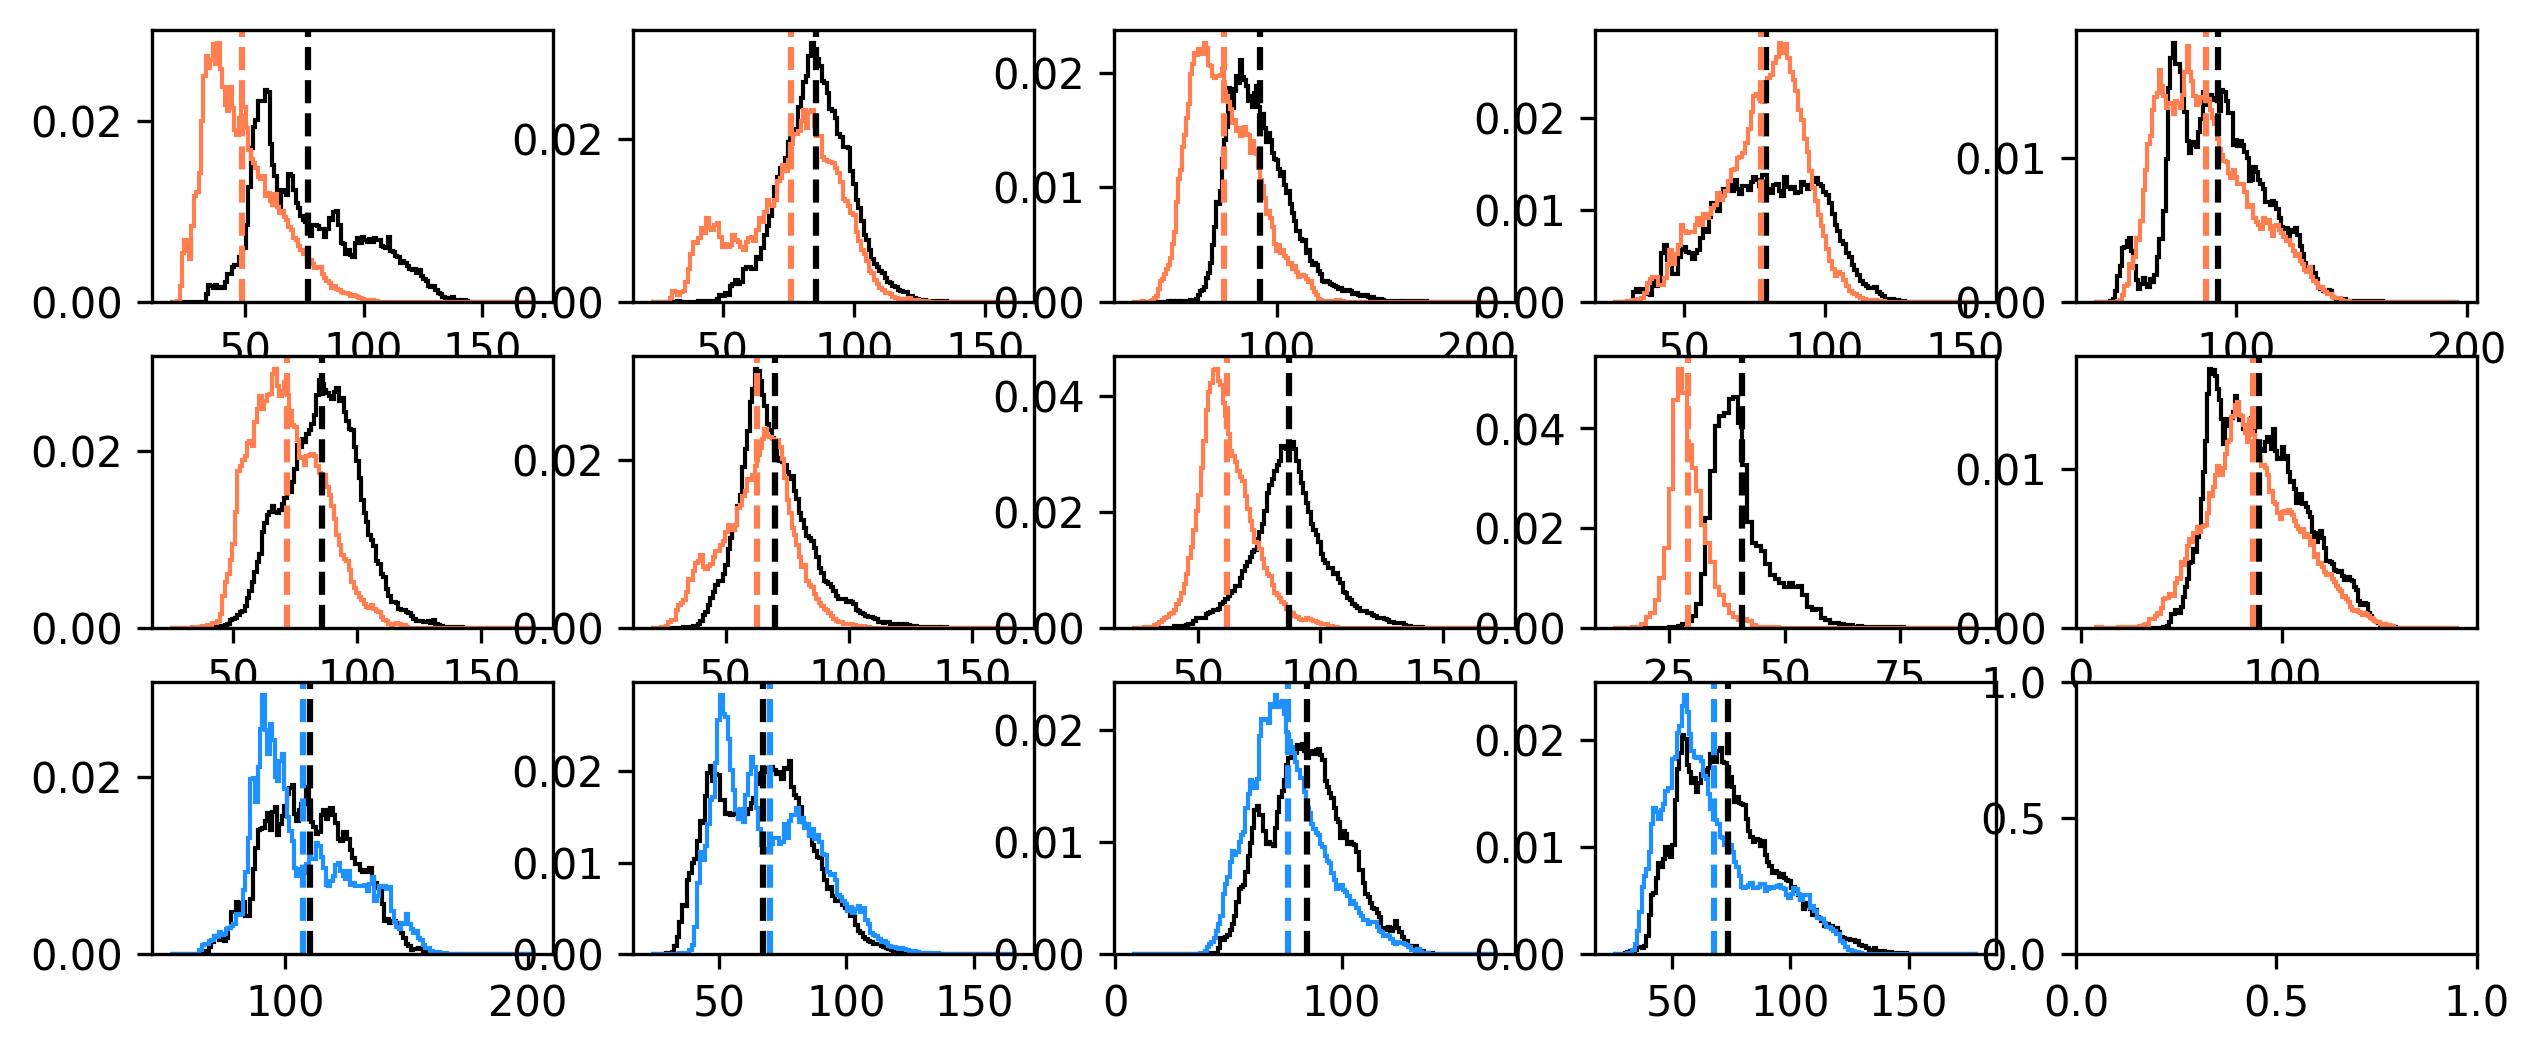

In [8]:
#Plotting Pupil Area histogram by mouse pre and post doi
fig, axs=plt.subplots(3,5,figsize=(10,4), dpi=300)
axs = axs.ravel()

for ii in range(0,len(PreDOI_PupilArea)):
    PreDOI_Data = PreDOI_PupilArea[ii]
    PostDOI_Data = PostDOI_PupilArea[ii]

    Pre_Weights = np.ones(len(PreDOI_Data))/len(PreDOI_Data)
    Post_Weights = np.ones(len(PostDOI_Data))/len(PostDOI_Data)
    bins = np.arange(np.nanmin(np.concatenate((PreDOI_Data,PostDOI_Data)))/1.2,np.nanmax(np.concatenate((PreDOI_Data,PostDOI_Data)))*1.2,1)
    if ii > 9:
        axs[ii].hist(PreDOI_Data, bins, weights = Pre_Weights, histtype='step',color = 'black')
        axs[ii].hist(PostDOI_Data, bins, weights = Post_Weights, histtype='step',color = 'dodgerblue')
        axs[ii].axvline(np.nanmean(PreDOI_Data),color = 'black',linestyle = '--')
        axs[ii].axvline(np.nanmean(PostDOI_Data),color = 'dodgerblue',linestyle = '--')
    else:
        axs[ii].hist(PreDOI_Data, bins, weights = Pre_Weights, histtype='step',color = 'black')
        axs[ii].hist(PostDOI_Data, bins, weights = Post_Weights, histtype='step',color = 'coral')
        axs[ii].axvline(np.nanmean(PreDOI_Data),color = 'black',linestyle = '--')
        axs[ii].axvline(np.nanmean(PostDOI_Data),color = 'coral',linestyle = '--')

IndexError: index 6 is out of bounds for axis 0 with size 0

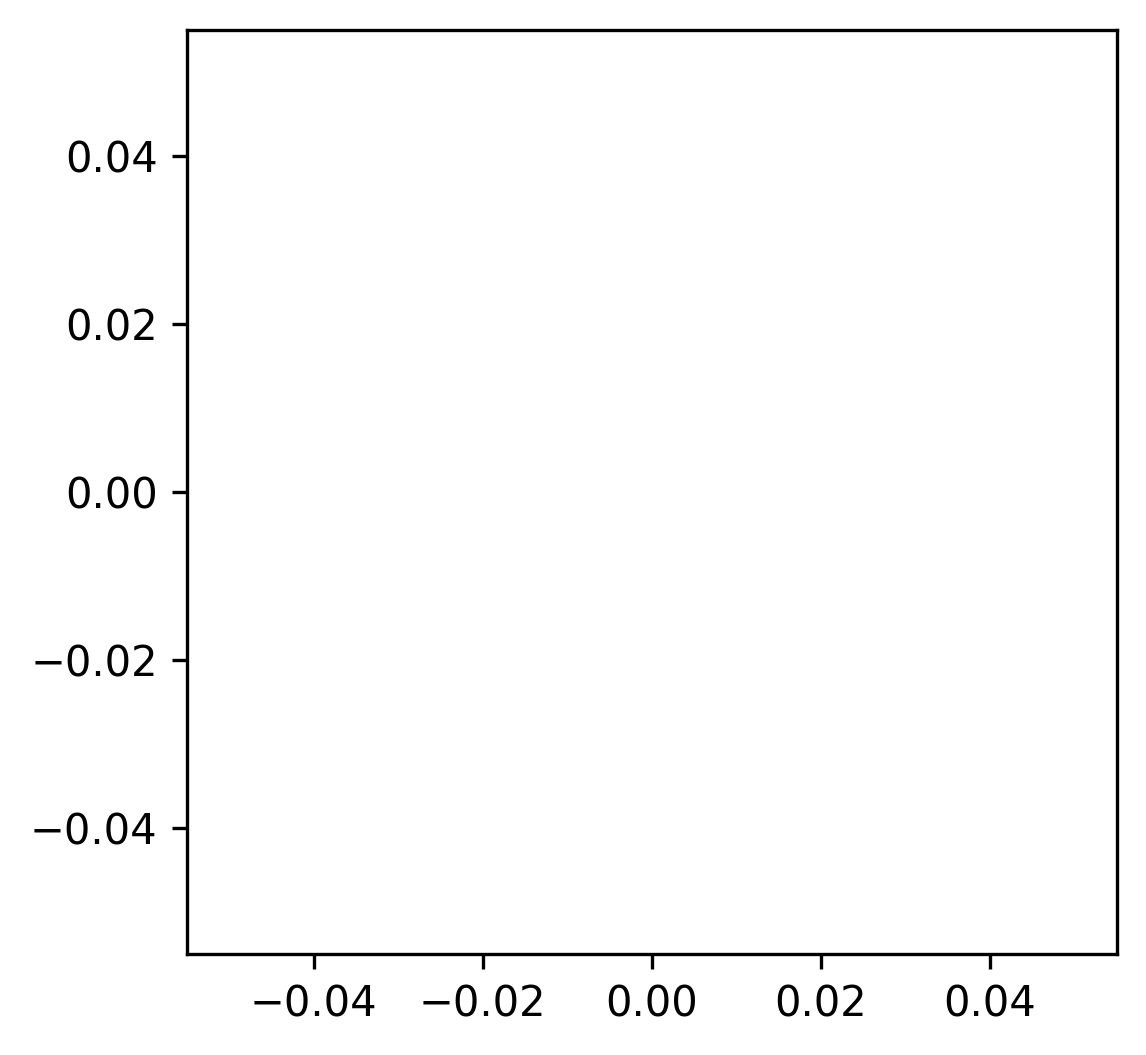

In [95]:
#Calculating Average Pupil Size over recording and plotting on scatter plot

Pre_Av = np.zeros(len(PreDOI_PupilArea))
Post_Av = np.zeros(len(PreDOI_PupilArea))
PupilArea_Dif = np.zeros(len(PreDOI_PupilArea))

for ii in range(0,len(PreDOI_PupilArea)):


   Pre_Av[ii] = np.nanmean(PreDOI_PupilArea[ii])
   Post_Av[ii] = np.nanmean(PostDOI_PupilArea[ii])
   PupilArea_Dif[ii] = np.nanmean(PostDOI_PupilArea[ii])-np.nanmean(PreDOI_PupilArea[ii])

fig, axs=plt.subplots(1,1,figsize=(4,4), dpi=300)
plt.scatter(Pre_Av[0:10],Post_Av[0:10],color = 'coral',edgecolor = 'black',zorder = 7)
plt.errorbar(x = np.nanmean(Pre_Av[0:10]),y = np.nanmean(Post_Av[0:10]),xerr = np.nanstd(Pre_Av[0:10])/np.sqrt(len(Pre_Av[0:10])),yerr = np.nanstd(Post_Av[0:10])/np.sqrt(len(Post_Av[0:10])),color= 'coral',linewidth=2,zorder = 8)

plt.scatter(Pre_Av[10:],Post_Av[10:],color = 'dodgerblue',edgecolor = 'black',zorder = 7)
plt.errorbar(x = np.nanmean(Pre_Av[10:]),y = np.nanmean(Post_Av[10:]),xerr = np.nanstd(Pre_Av[10:])/np.sqrt(len(Pre_Av[10:])),yerr=np.nanstd(Post_Av[10:])/np.sqrt(len(Post_Av[10:])),color= 'dodgerblue',linewidth=2,zorder = 8)

plt.scatter(Pre_Av[zz],Post_Av[zz],color = 'black',edgecolor = 'black',zorder = 8)

plt.plot([25,125],[25,125],linestyle='--',color = 'black')
plt.xlabel('Pre - Pupil Area')
plt.ylabel('Post - Pupil Area')
#plt.xlim(25,125)
#plt.ylim(25,125)
plt.xticks(np.arange(25,150,25))
plt.yticks(np.arange(25,150,25))
plt.grid(zorder = 8)
plt.gca().set_rasterized(True)
plt.gca().set_aspect('equal', 'box')


plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'I - PupilArea_PrePostInjection.eps'),dpi=300)



-1.8264490760741678
0.04637470197214698


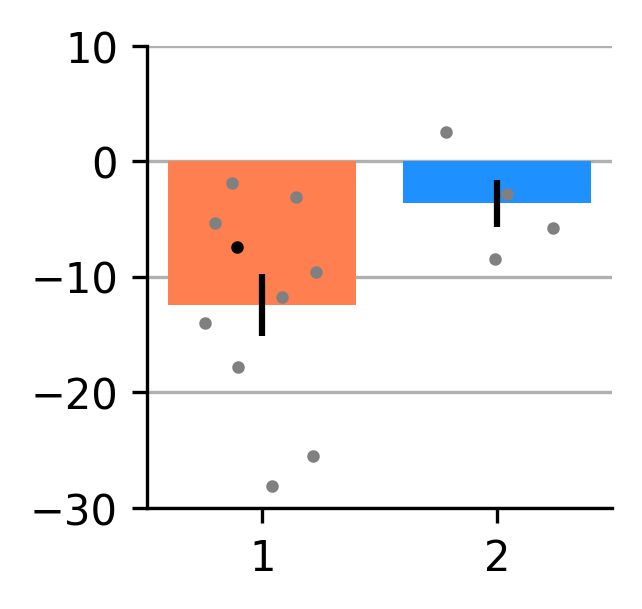

In [153]:
#Plotting change in pupil size 

fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

plt.bar(1,np.nanmean(PupilArea_Dif[0:10]),color = 'coral',zorder = 5)

plt.scatter(jitter(0,len(PupilArea_Dif[NotTheExampleMouse]),maxdist=0.25), PupilArea_Dif[NotTheExampleMouse],color='grey',zorder = 6,s=4)
plt.scatter(jitter(0,1,maxdist=0.25), PupilArea_Dif[zz],color='black',zorder = 6,s=4)

plt.errorbar(1,np.nanmean(PupilArea_Dif[0:10]),np.std(PupilArea_Dif[0:10])/np.sqrt(10),color='black',zorder = 6)

plt.bar(2,np.nanmean(PupilArea_Dif[10:]),color = 'dodgerblue',zorder = 5)
plt.scatter(jitter(1,len(PupilArea_Dif[10:]),maxdist=0.25), PupilArea_Dif[10:],color='grey',zorder = 6,s=4)
plt.errorbar(2,np.nanmean(PupilArea_Dif[10:]),np.std(PupilArea_Dif[10:])/np.sqrt(4),color='black',zorder = 6)
plt.grid(axis= 'y',zorder = 4)
plt.ylim(-30,10)
plt.yticks(ticks=[-30,-20,-10,0,10])
plt.xticks(ticks=[1,2])
#plt.gca().set_aspect('equal')
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)

fig.savefig(os.path.join(figpath,'I - ChangePupilArea_barplot.eps'),dpi=300)

t_stat, p_value = stats.ttest_ind(PupilArea_Dif[0:10],PupilArea_Dif[10:],alternative = 'less')
print(t_stat)
print(p_value)


In [96]:
Pre_Speed = np.zeros(len(PreDOI_Speed_CmSec))
Post_Speed = np.zeros(len(PostDOI_Speed_CmSec))

Pre_PercentTimeRunning = np.zeros(len(PreDOI_Speed_CmSec))
Post_PercentTimeRunning = np.zeros(len(PostDOI_Speed_CmSec))

Pre_Distance = np.zeros(len(PreDOI_Speed_CmSec))
Post_Distance = np.zeros(len(PostDOI_Speed_CmSec))
for ii in range(0,len(PostDOI_Speed_CmSec)):
   preData = PreDOI_Speed_CmSec[ii]
   postData = PostDOI_Speed_CmSec[ii]

   Pre_Speed[ii] = np.nanmean(preData[preData>2])
   Post_Speed[ii] = np.nanmean(postData[postData>2])

   Pre_Distance[ii] = np.nansum(preData[preData>2])/100000
   Post_Distance[ii] = np.nansum(postData[postData>2])/100000

   preData_mask = preData.copy()
   postData_mask = postData.copy()

   preData_mask[preData_mask<2] = 0
   postData_mask[postData_mask<2] = 0

   preData_mask[preData_mask>=2] = 1
   postData_mask[postData_mask>=2] = 1

   Pre_PercentTimeRunning[ii] = np.nansum(preData_mask)/len(preData_mask)
   Post_PercentTimeRunning[ii] = np.nansum(postData_mask)/len(postData_mask)
   

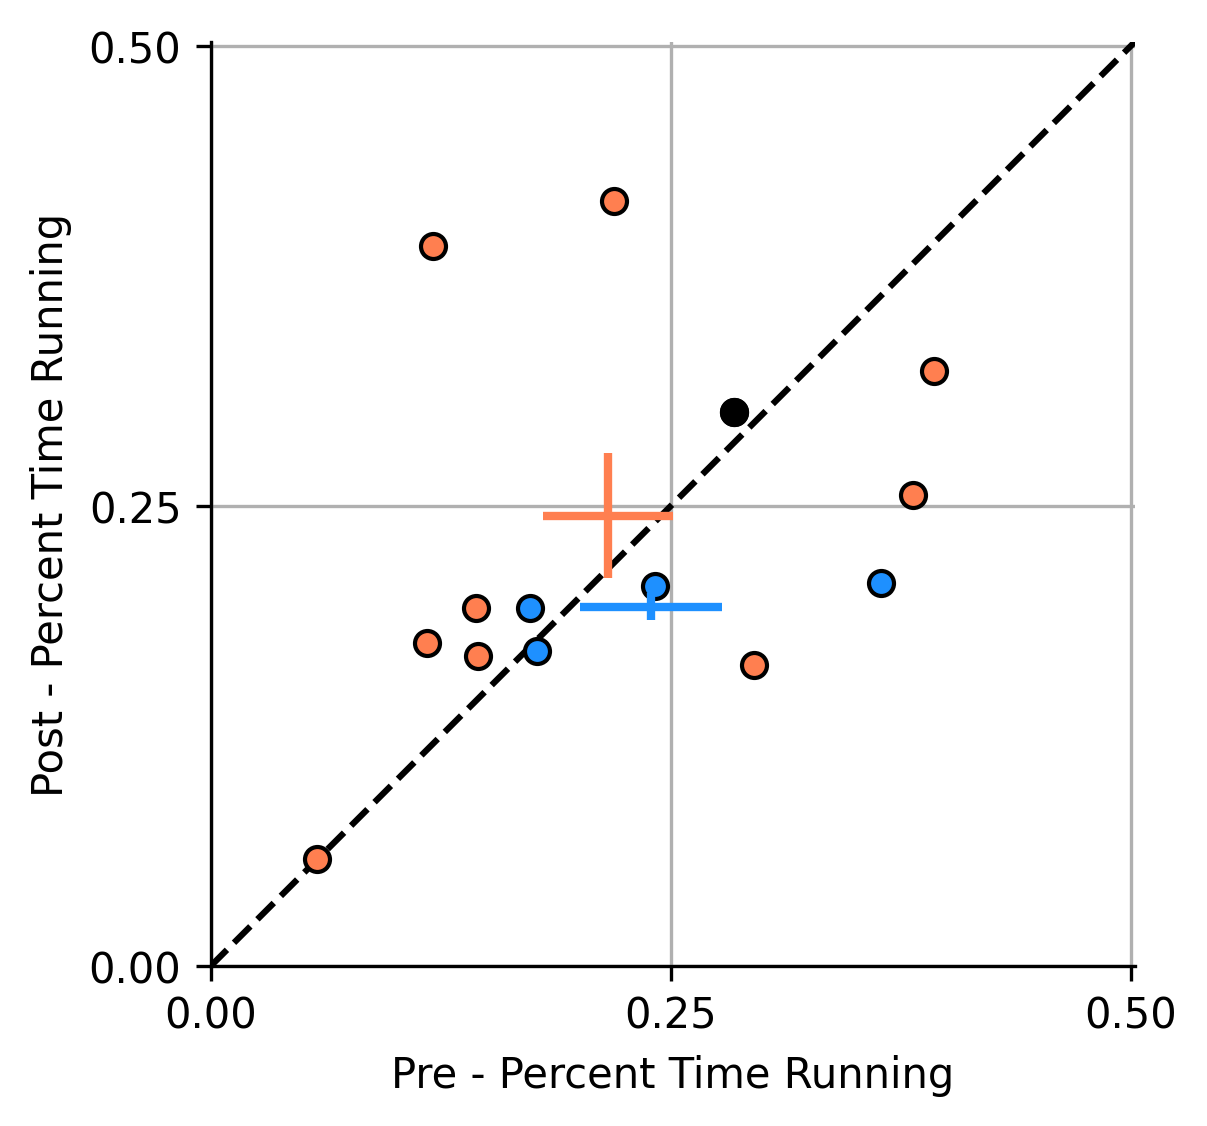

In [97]:
fig, axs=plt.subplots(1,1,figsize=(4,4), dpi=300)

plt.scatter(Pre_PercentTimeRunning[0:10],Post_PercentTimeRunning[0:10],color = 'coral',edgecolor = 'black',zorder = 7)
plt.scatter(Pre_PercentTimeRunning[zz],Post_PercentTimeRunning[zz],color = 'black',edgecolor = 'black',zorder = 8)
plt.scatter(Pre_PercentTimeRunning[10:],Post_PercentTimeRunning[10:],color = 'dodgerblue',edgecolor = 'black',zorder = 7)
plt.plot([0,1],[0,1],linestyle='--',color = 'black')

plt.errorbar(x = np.nanmean(Pre_PercentTimeRunning[0:10]),y = np.nanmean(Post_PercentTimeRunning[0:10]),xerr = np.nanstd(Pre_PercentTimeRunning[0:10])/np.sqrt(len(Pre_PercentTimeRunning[0:10])),yerr = np.nanstd(Post_PercentTimeRunning[0:10])/np.sqrt(len(Post_PercentTimeRunning[0:10])),color= 'coral',linewidth=2,zorder = 8)
plt.errorbar(x = np.nanmean(Pre_PercentTimeRunning[10:]),y = np.nanmean(Post_PercentTimeRunning[10:]),xerr = np.nanstd(Pre_PercentTimeRunning[10:])/np.sqrt(len(Pre_PercentTimeRunning[10:])),yerr = np.nanstd(Post_PercentTimeRunning[10:])/np.sqrt(len(Post_PercentTimeRunning[10:])),color= 'dodgerblue',linewidth=2,zorder = 8)

plt.xlabel('Pre - Percent Time Running')
plt.ylabel('Post - Percent Time Running')

plt.xlim(0,.502)
plt.ylim(0,.502)
plt.xticks(np.arange(0,.75,.25))
plt.yticks(np.arange(0,.75,.25))
plt.grid(zorder = 3)
plt.gca().set_rasterized(True)
plt.gca().set_aspect('equal', 'box')

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'H - PercentTimeRunning_injectionEffect.eps'),dpi=300)

1.0461482290036843
0.15805412620882667


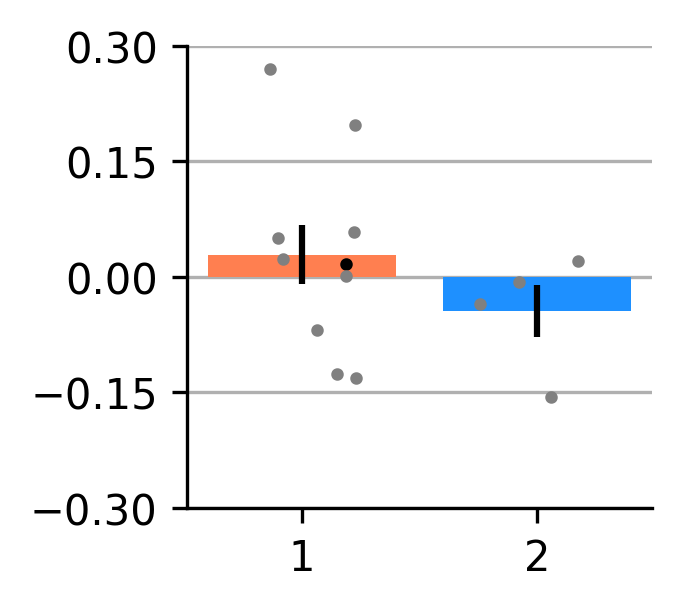

In [157]:
PercentRunning_Change = Post_PercentTimeRunning-Pre_PercentTimeRunning
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

plt.bar(1,np.nanmean(PercentRunning_Change[0:10]),color = 'coral',zorder = 5)
plt.scatter(jitter(0,1,maxdist=0.25), PercentRunning_Change[zz],color='black',zorder = 6,s=4)
plt.scatter(jitter(0,len(NotTheExampleMouse),maxdist=0.25), PercentRunning_Change[NotTheExampleMouse],color='grey',zorder = 6,s=4)
plt.errorbar(1,np.nanmean(PercentRunning_Change[0:10]),np.std(PercentRunning_Change[0:10])/np.sqrt(10),color='black',zorder = 6)

plt.bar(2,np.nanmean(PercentRunning_Change[10:]),color = 'dodgerblue',zorder = 5)
plt.scatter(jitter(1,len(PercentRunning_Change[10:]),maxdist=0.25), PercentRunning_Change[10:],color='grey',zorder = 6,s=4)
plt.errorbar(2,np.nanmean(PercentRunning_Change[10:]),np.std(PercentRunning_Change[10:])/np.sqrt(4),color='black',zorder = 6)
plt.grid(axis= 'y',zorder = 4)
plt.ylim(-.3,.3)
plt.yticks(ticks=[-.3,-.15,0,.15,.3])
plt.xticks(ticks=[1,2])
#plt.gca().set_aspect('equal')
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)

fig.savefig(os.path.join(figpath,'H - PercentRunning_InjectionEffect_BarPlot.eps'),dpi=300)


t_stat, p_value = stats.ttest_ind(PercentRunning_Change[0:10],PercentRunning_Change[10:],alternative = 'greater')
print(t_stat)
print(p_value)


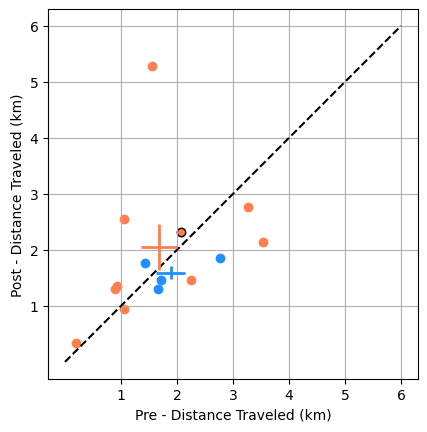

In [98]:

fig, axs=plt.subplots()

plt.scatter(Pre_Distance[0:10],Post_Distance[0:10],color = 'coral')
plt.scatter(Pre_Distance[zz],Post_Distance[zz],color = 'coral',edgecolor = 'black')
plt.scatter(Pre_Distance[10:],Post_Distance[10:],color = 'dodgerblue')
plt.plot([0,6],[0,6],linestyle='--',color = 'black')

plt.errorbar(x = np.nanmean(Pre_Distance[0:10]),y = np.nanmean(Post_Distance[0:10]),xerr = np.nanstd(Pre_Distance[0:10])/np.sqrt(len(Pre_Distance[0:10])),yerr = np.nanstd(Post_Distance[0:10])/np.sqrt(len(Post_Distance[0:10])),color= 'coral',linewidth=2)
plt.errorbar(x = np.nanmean(Pre_Distance[10:]),y = np.nanmean(Post_Distance[10:]),xerr = np.nanstd(Pre_Distance[10:])/np.sqrt(len(Pre_Distance[10:])),yerr = np.nanstd(Post_Distance[10:])/np.sqrt(len(Post_Distance[10:])),color= 'dodgerblue',linewidth=2)

plt.xlabel('Pre - Distance Traveled (km)')
plt.ylabel('Post - Distance Traveled (km)')

#plt.xlim(25,125)
#plt.ylim(25,125)
plt.xticks(np.arange(1,7,1))
plt.yticks(np.arange(1,7,1))
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().set_aspect('equal', 'box')
#fig.savefig(os.path.join(figpath,'DistanceTraveled_PrePostInjection.eps'),dpi=300)
#plt.close(fig)

In [158]:
#Calculating mouse position, surround vs center 

Barrier = 32.25*2.5 #This allows for a 2.5 inch ring around the edge of the arena

PercentCenter_Pre = np.zeros(len(PreDOI_X))
PercentCenter_Post = np.zeros(len(PreDOI_X))

for ii in range(0,len(PreDOI_X)):
    PreX = PreDOI_X[ii]
    PreY = PreDOI_Y[ii]
    
    BottomY = np.mean(BottomWall,axis=1)[ii] 
    TopY = np.mean(TopWall,axis=1)[ii]
    LeftX = np.mean(LeftWall,axis=1)[ii]
    RightX = np.mean(RightWall,axis=1)[ii]
    
    PostX = PostDOI_X[ii]
    PostY = PostDOI_Y[ii]
    print(np.nanmean(PostX))
    Center_Mask_Pre = np.argwhere((PreX>(LeftX+Barrier)) & (PreX<(RightX-Barrier)) & (PreY>(TopY+Barrier)) & (PreY<(BottomY-Barrier)))
    Center_Mask_Post = np.argwhere((PostX>(LeftX+Barrier)) & (PostX<(RightX-Barrier)) & (PostY>(TopY+Barrier)) & (PostY<(BottomY-Barrier)))
    
    PercentCenter_Pre[ii] = len(Center_Mask_Pre)/np.nansum(~np.isnan(PreX))
    PercentCenter_Post[ii] = len(Center_Mask_Post)/np.nansum(~np.isnan(PostX))


408.50386874534917
453.5553676294592
355.1962453825438
344.6485759848051
410.6565572617928
448.7175342047006
398.973446028488
376.3884123023342
223.2059429675012
282.5970431762322
282.5970431762322
466.48183845943413
238.5724174083087
160.36655087350996


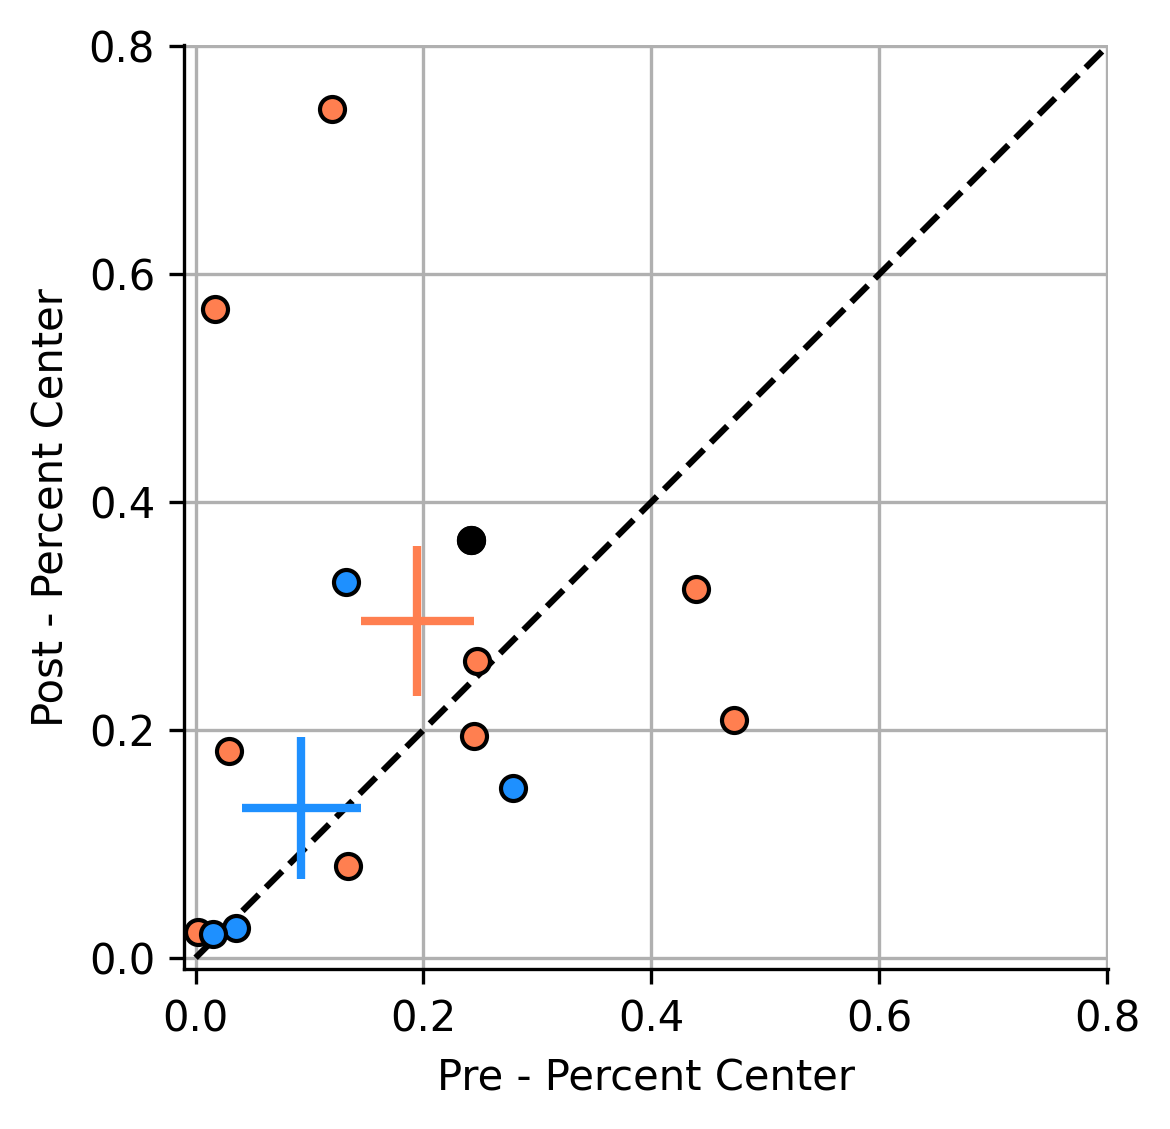

In [160]:
#Plotting scatter plot of time spent in center vs surround 

fig, axs=plt.subplots(1,1,figsize=(4,4), dpi=300)

plt.scatter(PercentCenter_Pre[0:10],PercentCenter_Post[0:10],color = 'coral',edgecolor = 'black',zorder = 7)
plt.scatter(PercentCenter_Pre[zz],PercentCenter_Post[zz],color = 'black',edgecolor = 'black',zorder = 8)
plt.scatter(PercentCenter_Pre[10:],PercentCenter_Post[10:],color = 'dodgerblue',edgecolor = 'black',zorder = 7)
plt.plot([0,1],[0,1],linestyle='--',color = 'black')

plt.errorbar(x = np.nanmean(PercentCenter_Pre[0:10]),y = np.nanmean(PercentCenter_Post[0:10]),xerr = np.nanstd(PercentCenter_Pre[0:10])/np.sqrt(len(PercentCenter_Pre[0:10])),yerr = np.nanstd(PercentCenter_Post[0:10])/np.sqrt(len(PercentCenter_Post[0:10])),color= 'coral',linewidth=2,zorder = 8)
plt.errorbar(x = np.nanmean(PercentCenter_Pre[9:]),y = np.nanmean(PercentCenter_Post[10:]),xerr = np.nanstd(PercentCenter_Pre[10:])/np.sqrt(len(PercentCenter_Pre[10:])),yerr = np.nanstd(PercentCenter_Post[10:])/np.sqrt(len(PercentCenter_Post[10:])),color= 'dodgerblue',linewidth=2,zorder = 8)

plt.xlabel('Pre - Percent Center')
plt.ylabel('Post - Percent Center')

plt.xlim(-0.01,.801)
plt.ylim(-0.01,.801)
plt.xticks(np.arange(0,1,.2))
plt.yticks(np.arange(0,1,.2))
plt.grid(zorder = 3)
plt.gca().set_rasterized(True)
plt.gca().set_aspect('equal', 'box')

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'G - PercentCenterOfArena_PrePostInjection.eps'),dpi=300)
#plt.close(fig)


0.5600977266655837
0.292858560955532


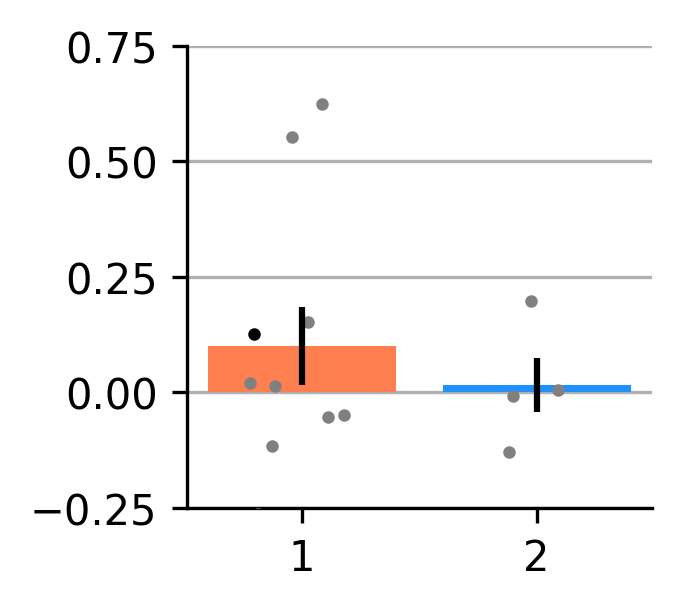

In [163]:
#Bar plot showing change in time spent in cnter vs surround 
PercentCenter_Change = PercentCenter_Post-PercentCenter_Pre

fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

plt.bar(1,np.nanmean(PercentCenter_Change[0:10]),color = 'coral',zorder = 5)
plt.scatter(jitter(0,1,maxdist=0.25), PercentCenter_Change[zz],color='black',zorder = 6,s=4)
plt.scatter(jitter(0,len(NotTheExampleMouse),maxdist=0.25), PercentCenter_Change[NotTheExampleMouse],color='grey',zorder = 6,s=4)
plt.errorbar(1,np.nanmean(PercentCenter_Change[0:10]),np.std(PercentCenter_Change[0:10])/np.sqrt(10),color='black',zorder = 6)

plt.bar(2,np.nanmean(PercentCenter_Change[10:]),color = 'dodgerblue',zorder = 5)
plt.scatter(jitter(1,len(PercentCenter_Change[10:]),maxdist=0.25), PercentCenter_Change[10:],color='grey',zorder = 6,s=4)
plt.errorbar(2,np.nanmean(PercentCenter_Change[10:]),np.std(PercentCenter_Change[10:])/np.sqrt(4),color='black',zorder = 6)
plt.grid(axis= 'y',zorder = 4)
plt.ylim(-.25,.75)
plt.yticks(ticks=[-.25,0,.25,.5,.75])
plt.xticks(ticks=[1,2])
#plt.gca().set_aspect('equal')
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)

fig.savefig(os.path.join(figpath,'G - PercentCenter_InjectionEffect_BarPlot.eps'),dpi=300)


t_stat, p_value = stats.ttest_ind(PercentCenter_Change[0:10],PercentCenter_Change[10:],alternative = 'greater')
print(t_stat)
print(p_value)



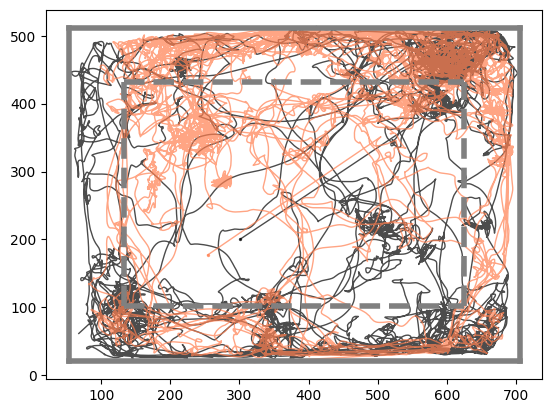

In [164]:
#Creating mouse location in box plot with center surround comparison - Fig 1 C (maybe)

BottomY = np.ceil(np.max(BottomWall,axis=1)[zz])+1
TopY = np.floor(np.min(TopWall,axis=1)[zz])
LeftX = np.floor(np.min(LeftWall,axis=1)[zz])
RightX = np.ceil(np.max(RightWall,axis=1)[zz])

fig, axs=plt.subplots()
plt.plot(PreDOI_X[zz],PreDOI_Y[zz],color = 'black',alpha = .7,linewidth =1,zorder =5)
plt.scatter(PreDOI_X[zz][0],PreDOI_Y[zz][0],color = 'black',alpha = .7,s=2,zorder =5)
plt.plot(PostDOI_X[zz],PostDOI_Y[zz],color = 'coral',alpha = .7,linewidth =1,zorder =5)
plt.scatter(PostDOI_X[zz][0],PostDOI_Y[zz][0],color = 'coral',alpha = .7,s=2,zorder =5)
#fig.savefig((figpath + ' All Mice - Saccades Per Minute.png'), dpi=300)
#plt.close(fig)
#Generate walls of Arena
plt.plot([LeftX,LeftX],[TopY,BottomY],color = 'grey',linewidth=4,zorder =6)
plt.plot([RightX,RightX],[TopY,BottomY],color = 'grey',linewidth=4,zorder =6)
plt.plot([LeftX,RightX],[BottomY,BottomY],color = 'grey',linewidth=4,zorder =6)
plt.plot([LeftX,RightX],[TopY,TopY],color = 'grey',linewidth=4,zorder =6)

#Plotting Center vs Surround
plt.plot([LeftX+Barrier,LeftX+Barrier],[TopY+Barrier,BottomY-Barrier],color = 'grey',linestyle='--',linewidth=4,zorder =6)
plt.plot([RightX-Barrier,RightX-Barrier],[TopY+Barrier,BottomY-Barrier],color = 'grey',linestyle='--',linewidth=4,zorder =6)
plt.plot([LeftX+Barrier,RightX-Barrier],[BottomY-Barrier,BottomY-Barrier],color = 'grey',linestyle='--',linewidth=4,zorder =6)
plt.plot([LeftX+Barrier,RightX-Barrier],[TopY+Barrier,TopY+Barrier],color = 'grey',linestyle='--',linewidth=4,zorder =6)
plt.gca().set_rasterized(True)

#fig.savefig(os.path.join(figpath,'Example_PositionTrace_PrePostDOI.eps'),dpi=300)


In [11]:
#Doing analysis for making figure 1 D, example traces of speed, head eye and gaze position with gaze events

ExampleRecordingPath = RecordingsToUse[zz] #zz is our example mouse

#Figuring out what type of recording it is based on the number of FM blocks
FolderContent = os.listdir(ExampleRecordingPath)
count = 0
for zzz in FolderContent:
    if zzz.startswith("fm"):
        count = count + 1 

# If 2 FM Blocks then FM1 is Pre DOI and FM2 is Post DOI
if count == 2:
    PreFM_Path = ExampleRecordingPath + '/fm1'
    Items = os.listdir(PreFM_Path)
    for names in Items:
        if names.endswith("ephys_props.h5"):
            Pre_EphysData = PreFM_Path + '/' + names
        if names.endswith("imu.nc"):
            PreDOI_IMU_File = PreFM_Path + '/' + names
        if names.endswith("REYE.nc"):
            PreDOI_REYE_File = PreFM_Path + '/' + names
        if names.endswith("_resnet50_TopCameraTrackingFeb13shuffle1_500000_filtered.h5"):
            PreDOI_Top_File = PreFM_Path + '/' + names
        
# If 4 FM Blocks then FM2 is Pre DOI and FM4 is Post DOI (FM1 and FM3 are dark recordings)
if count == 4:
    PreFM_Path = ExampleRecordingPath + '/fm2'
    Items = os.listdir(PreFM_Path)
    for names in Items:
        if names.endswith("ephys_props.h5"):
            Pre_EphysData = PreFM_Path + '/' + names
        if names.endswith("imu.nc"):
            PreDOI_IMU_File = PreFM_Path + '/' + names
        if names.endswith("REYE.nc"):
            PreDOI_REYE_File = PreFM_Path + '/' + names
        if names.endswith("_resnet50_TopCameraTrackingFeb13shuffle1_500000_filtered.h5"):
            PreDOI_Top_File = PreFM_Path + '/' + names
########################################
#Loading Files

Pre_EphysData = pd.read_hdf(Pre_EphysData)
PreDOI_IMU = xr.open_dataset(PreDOI_IMU_File)
PreDOI_REYE = xr.open_dataset(PreDOI_REYE_File)
PreDOI_Top_pts, PreDOI_Top_ptnames = open_dlc_h5(PreDOI_Top_File)

#Calculating the number of gaze events per minute
Pre_LeftGaze_Times = Pre_EphysData.loc[:,'FmLt_gazeshift_leftT']
Pre_RightGaze_Times = Pre_EphysData.loc[:,'FmLt_gazeshift_rightT']
Pre_LeftComp_Times = Pre_EphysData.loc[:,'FmLt_compensatory_leftT']
Pre_RightComp_Times = Pre_EphysData.loc[:,'FmLt_compensatory_rightT']

t0 = Pre_EphysData.at[Pre_EphysData.index[0],'FmLt_t0']
Pre_eyeT = Pre_EphysData.at[Pre_EphysData.index[0],'FmLt_eyeT']
#################
##IMU Data
PreDOI_gyroZ = PreDOI_IMU.__xarray_dataarray_variable__.sel(channel='gyro_z').values
PreDOI_IMUT = PreDOI_IMU.sample

sample_freq = 300
Pre_num_samples = np.size(PreDOI_gyroZ)
Pre_newTime = list(np.array(np.linspace(0, Pre_num_samples-1, Pre_num_samples) / sample_freq))

##Eye Data
PreDOI_Eye_Video = PreDOI_REYE['REYE_video'].astype(np.uint8)
PreDOI_Eye_Time = PreDOI_REYE.timestamps.copy().values
PreDOI_Eye_Params = PreDOI_REYE['REYE_ellipse_params'] 

PreDOI_theta = np.rad2deg(PreDOI_Eye_Params.sel(ellipse_params = 'theta').values)
PreDOI_theta = PreDOI_theta - np.nanmean(PreDOI_theta)

PreDOI_dEYE = np.diff(PreDOI_theta)
PreDOI_dEYE_dps = PreDOI_dEYE/np.diff(PreDOI_Eye_Time)

Pre_DOIShortaxis = PreDOI_Eye_Params.sel(ellipse_params='shortaxis').values[:-1]
Pre_DOILongaxis = PreDOI_Eye_Params.sel(ellipse_params='shortaxis').values[:-1]
PreDOI_PupilArea= Pre_DOIShortaxis*np.pi


######################################
#Calculating Speed
Running_Threshold = 2 

X_Pts_PreDOI = PreDOI_Top_pts.iloc[:,0]
Y_Pts_PreDOI = PreDOI_Top_pts.iloc[:,1]

SmoothX_PreDOI = fme.convfilt(fme.nanmedfilt(X_Pts_PreDOI,7).squeeze(),box_pts=20)
SmoothY_PreDOI = fme.convfilt(fme.nanmedfilt(Y_Pts_PreDOI,7).squeeze(),box_pts=20)

PreDOI_Speed_CmSec = ((np.sqrt(np.diff((SmoothX_PreDOI))**2 + np.diff((SmoothY_PreDOI))**2))*60*50.165/720)


#Interpolate dHead to Eye Camera Data
PreDOI_dHead = scipy.interpolate.interp1d(PreDOI_IMUT, PreDOI_gyroZ, bounds_error=False)(PreDOI_Eye_Time)[:-1]
PreDOI_pYaw = np.nancumsum(PreDOI_dHead)*0.016
PreDOI_pYaw = PreDOI_pYaw - np.nanmean(PreDOI_pYaw)
PreDOI_pGaze = PreDOI_pYaw + PreDOI_theta[:-1]
PreDOI_theta = PreDOI_theta.copy()[:-1]
PreDOI_dGaze = PreDOI_dEYE_dps + PreDOI_dHead

TopT = read_timestamp_file(r'D:\080224\J705RT\fm1\080224_J705RT_control_Rig2_fm1_TOP1_BonsaiTS.csv')
PreDOI_Speed_CmSec_Interp = scipy.interpolate.interp1d(TopT[:-1], PreDOI_Speed_CmSec, bounds_error=False)(PreDOI_Eye_Time)[:-1]


shifted_head = 60  #criterion for a head movement in deg/sec
still_gaze = 120   #criterion for a compensatory eye/head mvmnt in deg/sec
shifted_gaze = 240 #criterion for a gaze shift in deg/sec


# match timestamps to ephys data - Pre
Pre_eyeT = PreDOI_Eye_Time - Pre_EphysData.iloc[0,12]
Pre_imuT_raw = PreDOI_IMUT - Pre_EphysData.iloc[0,12]
Pre_topT = TopT-Pre_EphysData.iloc[0,12]

lag_range = np.arange(-0.2, 0.2, 0.002)
cc = np.zeros(np.shape(lag_range))
t1 = np.arange(5, len(PreDOI_dEYE)/60 - 120, 20).astype(int)
t2 = t1 + 60
Pre_offset = np.zeros(np.shape(t1))
ccmax = np.zeros(np.shape(t1))
Pre_imu_interp = scipy.interpolate.interp1d(Pre_imuT_raw, PreDOI_gyroZ)

for tstart in tqdm(range(len(t1))):

    for l in range(len(lag_range)):
        try:
            c, lag = fme.nanxcorr(-PreDOI_dEYE[t1[tstart]*60 : t2[tstart]*60],
                        Pre_imu_interp(Pre_eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                        1)
            cc[l] = c[1]

        except:
            cc[l] = np.nan

    Pre_offset[tstart] = lag_range[np.argmax(cc)]    
    ccmax[tstart] = np.max(cc)

Pre_offset[ccmax<0.2] = np.nan

# Fit regression to timing drift
model = sklearn.linear_model.LinearRegression()
Pre_dataT = np.array(Pre_eyeT[t1*60 + 30*60])

model.fit(Pre_dataT[~np.isnan(Pre_offset)].reshape(-1,1),
            Pre_offset[~np.isnan(Pre_offset)]) 
            
Pre_ephys_offset = model.intercept_
Pre_ephys_drift_rate = model.coef_

Pre_imuT = Pre_imuT_raw - (Pre_ephys_offset + Pre_imuT_raw * Pre_ephys_drift_rate)



model_dt = 0.025
Pre_model_t = np.arange(0,np.nanmax(Pre_eyeT), model_dt)

Pre_dHead = scipy.interpolate.interp1d(Pre_imuT,
                                        PreDOI_gyroZ,
                                        bounds_error=False)(Pre_eyeT)[:-1]

Pre_dHead = Pre_dHead - np.nanmean(Pre_dHead)


Pre_tmp_eyeT = PreDOI_Eye_Time.flatten()[:-1]

Pre_gazeL = Pre_tmp_eyeT[(PreDOI_dHead > shifted_head) & (PreDOI_dGaze > shifted_gaze)]
Pre_gazeR = Pre_tmp_eyeT[(PreDOI_dHead < -shifted_head) & (PreDOI_dGaze < -shifted_gaze)]


Pre_gazeL = fme.drop_repeat_events(Pre_gazeL)
Pre_gazeR = fme.drop_repeat_events(Pre_gazeR)
AllGazeTimes = np.concatenate((Pre_gazeL,Pre_gazeR))


100%|██████████| 133/133 [02:03<00:00,  1.08it/s]


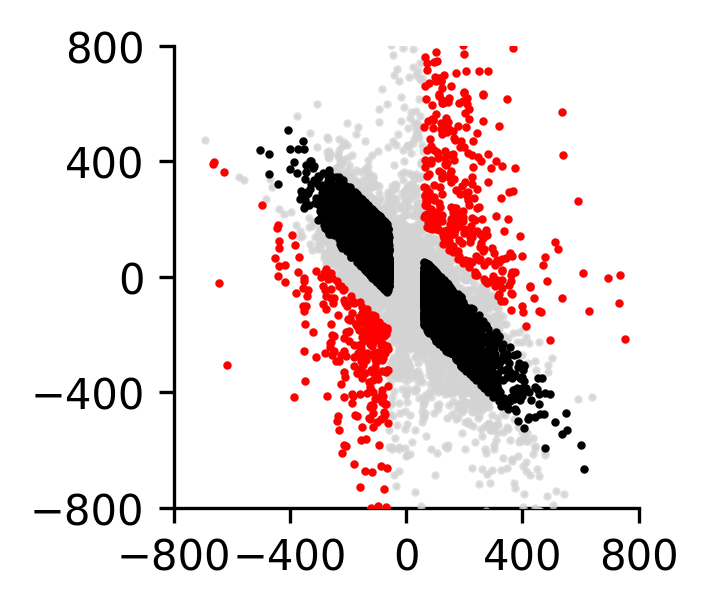

In [12]:
dEyeData = PreDOI_dEYE_dps#-np.nanmean(PreDOI_dEYE_dps)
dHeadData = Pre_dHead#-np.nanmean(Pre_dHead)

dHeadData = dHeadData[::4]
dEyeData = dEyeData[::4]

dGazeData = dEyeData + dHeadData


GazeEventsL = np.argwhere((dHeadData > 60) & (dGazeData>240)) 
GazeEventsR = np.argwhere((dHeadData <- 60) & (dGazeData<-240)) 

CompEventsL = np.argwhere((dHeadData > 60) & (dGazeData<120) & (dGazeData >-120))
CompEventsR = np.argwhere((dHeadData < -60) & (dGazeData<120)  & (dGazeData>-120))



fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.scatter(dHeadData,dEyeData,color = 'lightgrey',s=1,zorder = 3,alpha=.75)
plt.scatter(dHeadData[GazeEventsL],dEyeData[GazeEventsL],color = 'red',s=1,zorder = 5)
plt.scatter(dHeadData[CompEventsL],dEyeData[CompEventsL],color = 'black',s=1,zorder = 5)

plt.scatter(dHeadData[GazeEventsR],dEyeData[GazeEventsR],color = 'red',s=1,zorder = 5)
plt.scatter(dHeadData[CompEventsR],dEyeData[CompEventsR],color = 'black',s=1,zorder = 5)
plt.xlim(-800,800)
plt.ylim(-800,800)
plt.xticks(ticks = [-800,-400,0,400,800])
plt.yticks(ticks = [-800,-400,0,400,800])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'dHead-dEye Plot.eps'),dpi=300)

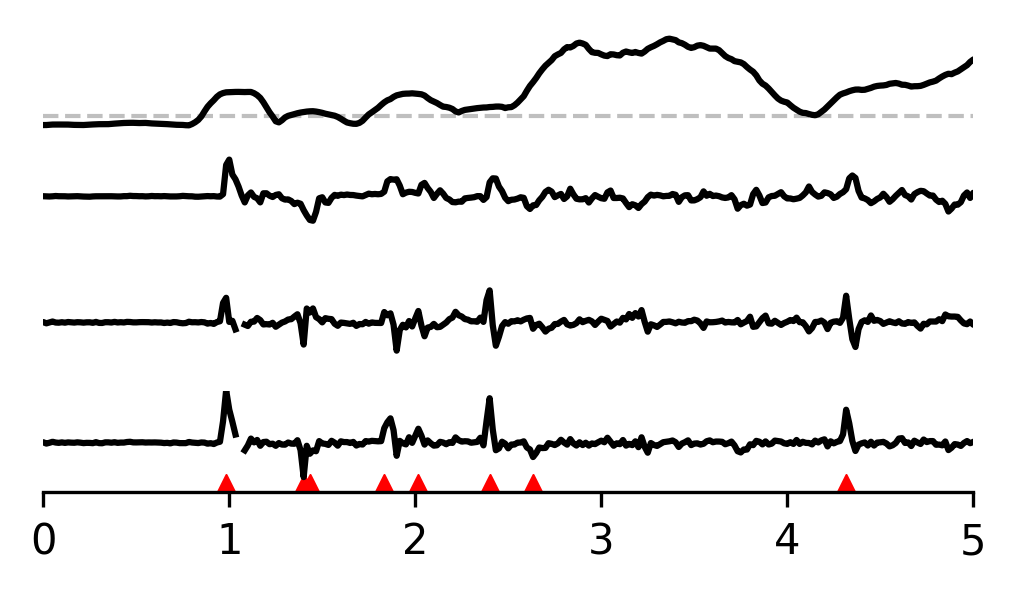

In [107]:
LeftGaze =  np.argwhere((PreDOI_dHead > shifted_head) & (PreDOI_dGaze > shifted_gaze))
RightGaze = np.argwhere((PreDOI_dHead < -shifted_head) & (PreDOI_dGaze < -shifted_gaze))
Pre_gazeL = drop_repeat_events(LeftGaze, win = 1.2)
Pre_gazeR = drop_repeat_events(RightGaze, win = 1.2)


fig, axs=plt.subplots(4,1,figsize=(4, 2), dpi=300,sharex= True)
axs = axs.ravel()

axs[0].plot(PreDOI_Speed_CmSec_Interp,'k-',linewidth = 1.5,zorder = 4)
axs[0].axhline(2,color='grey',linestyle='--',alpha=.5,linewidth = 1,zorder = 3)
axs[1].plot(PreDOI_dHead,'k-',linewidth = 1.5)
axs[2].plot(PreDOI_dEYE_dps,'k-',linewidth = 1.5)
axs[3].plot(PreDOI_dGaze,'k-',linewidth = 1.5)
axs[3].scatter(Pre_gazeL,np.ones(len(Pre_gazeL))*-1000,marker="^",color = 'red',linewidth = .5)
axs[3].scatter(Pre_gazeR,np.ones(len(Pre_gazeR))*-1000,marker="^",color = 'red',linewidth = .5)

axs[0].set_ylim(-1,10)
axs[2].set_ylim(-1100,1150)
axs[2].set_ylim(-1100,1150)
axs[3].set_ylim(-1100,1150)


axs[0].set_yticks(ticks=[0,20])

#start = 82600
start = 82600
window = 5*60

axs[0].set_xlim(start,start+window)


axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)
axs[0].spines.bottom.set_visible(False)
axs[0].spines.top.set_visible(False)
axs[0].spines.right.set_visible(False)
axs[0].spines.left.set_visible(False)

axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)
axs[1].spines.bottom.set_visible(False)
axs[1].spines.top.set_visible(False)
axs[1].spines.right.set_visible(False)
axs[1].spines.left.set_visible(False)

axs[2].get_xaxis().set_visible(False)
axs[2].get_yaxis().set_visible(False)
axs[2].spines.bottom.set_visible(False)
axs[2].spines.top.set_visible(False)
axs[2].spines.right.set_visible(False)
axs[2].spines.left.set_visible(False)

axs[3].get_yaxis().set_visible(False)
axs[3].spines.top.set_visible(False)
axs[3].spines.right.set_visible(False)
axs[3].spines.left.set_visible(False)


axs[3].set_xticks(ticks = np.arange(start,start+window+60,60),labels= [0,1,2,3,4,5])
#fig.savefig(os.path.join(figpath,'D - Example_BehaviorTraces_5s.eps'),dpi=300)

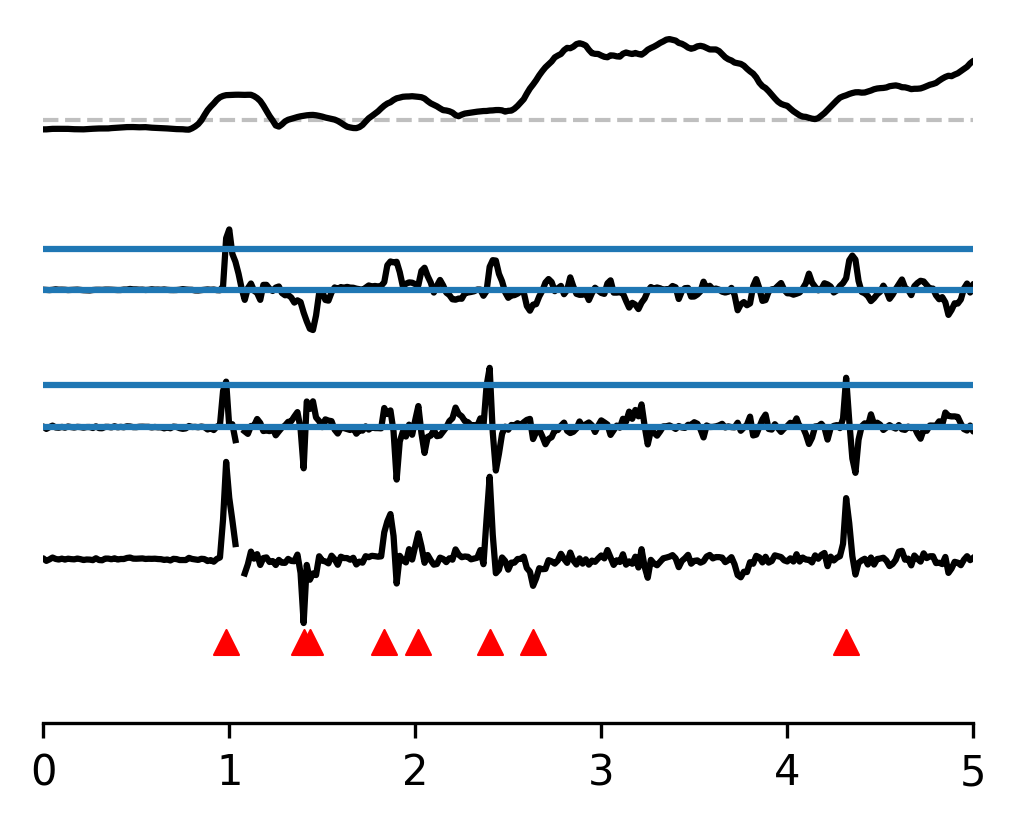

In [136]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(4,3),dpi=300)
gs = gridspec.GridSpec(2,1, height_ratios=[1,5])

ax0 = plt.subplot(gs[0])
ax0.plot(PreDOI_Speed_CmSec_Interp,'k-',linewidth = 1.5,zorder = 4)
ax0.axhline(2,color='grey',linestyle='--',alpha=.5,linewidth = 1,zorder = 3)

ax0.set_xlim(start,start+window)
ax0.get_xaxis().set_visible(False)
ax0.get_yaxis().set_visible(False)
ax0.spines.bottom.set_visible(False)
ax0.spines.top.set_visible(False)
ax0.spines.right.set_visible(False)
ax0.spines.left.set_visible(False)
ax0.set_ylim(-1,20)
ax0.set_yticks(ticks=[0,20])

ax1 = plt.subplot(gs[1])
ax1.plot((PreDOI_dHead*2)+6500,'k-',linewidth = 1.5)
ax1.plot((PreDOI_dEYE_dps*2)+3200,'k-',linewidth = 1.5)
ax1.plot((PreDOI_dGaze*2),'k-',linewidth = 1.5)
ax1.scatter(Pre_gazeL,np.ones(len(Pre_gazeL))*-2000,marker="^",color = 'red',linewidth = .5)
ax1.scatter(Pre_gazeR,np.ones(len(Pre_gazeR))*-2000,marker="^",color = 'red',linewidth = .5)

ax1.set_xlim(start,start+window)
#ax1.get_xaxis().set_visible(False)
ax1.get_yaxis().set_visible(False)
#ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax1.spines.right.set_visible(False)
ax1.spines.left.set_visible(False)

ax1.axhline(3200)
ax1.axhline(4200)
ax1.axhline(6500)
ax1.axhline(7500)

ax1.set_xticks(ticks = np.arange(start,start+window+60,60),labels= [0,1,2,3,4,5])

#plt.tight_layout() # Adjusts subplot params for a tight layout
#plt.show()
#fig.savefig(os.path.join(figpath,'D - Example_BehaviorTraces_5s.eps'),dpi=300)


In [151]:
np.nanmean(PreDOI_pYaw_gazeL[:,0:45],axis=1)

array([          nan, -177.05389774, -377.65692715, -400.88828758,
       -400.63042186, -409.03438992, -408.46475866, -407.85683934,
       -401.9787797 , -401.44508173, -341.26076732, -341.0858486 ,
       -320.48536262, -312.36468228, -312.61384178, -332.75553411,
       -333.07192344, -333.97650834, -376.45874558, -376.6387423 ,
       -377.42200569, -377.52240967, -372.83976655, -372.094134  ,
       -371.37244053, -350.75653231, -351.95319087, -373.20018905,
       -374.0454968 , -375.98091861, -376.44650861, -377.39840566,
       -376.13398434, -309.24142295, -309.80282608, -309.47904346,
       -296.65040614, -286.63929875, -279.96295213, -280.18596416,
       -278.15443929, -274.6481432 , -274.28146669, -269.21412423,
       -268.39927615, -231.21110403, -230.05747412, -212.88264655,
       -212.19215787, -210.89054673, -210.72453   , -179.70047179,
       -281.1456857 , -281.90589889, -259.21375458, -242.40024678,
       -226.92128968, -225.68080764, -195.67495365, -263.29790

In [152]:
PreDOI_theta_gazeL_Normed = PreDOI_theta_gazeL - np.nanmean(PreDOI_theta_gazeL[:,0:45],axis=1)[:,None]
PreDOI_pYaw_gazeL_Normed = PreDOI_pYaw_gazeL - np.nanmean(PreDOI_pYaw_gazeL[:,0:45],axis=1)[:,None]
PreDOI_pGaze_gazeL_Normed = PreDOI_pGaze_gazeL - np.nanmean(PreDOI_pGaze_gazeL[:,0:45],axis=1)[:,None]

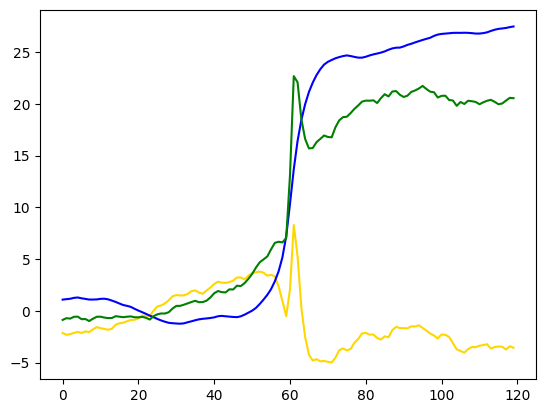

In [153]:
plt.plot(np.nanmean(PreDOI_theta_gazeL_Normed,axis=0),color = 'gold')
plt.plot(np.nanmean(PreDOI_pYaw_gazeL_Normed,axis=0),color = 'blue')
plt.plot(np.nanmean(PreDOI_pGaze_gazeL_Normed,axis=0),color = 'green')

In [16]:
#Plotting average gaze during gaze shifts before and after doi

PreDOI_pGaze_gazeL_Norm = PreDOI_pGaze_gazeL - PreDOI_pGaze_gazeL[:,53][:,None]
PostDOI_pGaze_gazeL_Norm = PostDOI_pGaze_gazeL - PostDOI_pGaze_gazeL[:,53][:,None]
PreDOI_pGaze_gazeR_Norm = PreDOI_pGaze_gazeR - PreDOI_pGaze_gazeR[:,53][:,None]
PostDOI_pGaze_gazeR_Norm = PostDOI_pGaze_gazeR - PostDOI_pGaze_gazeR[:,53][:,None]
PreDOI_pGaze_compL_Norm = PreDOI_pGaze_compL - PreDOI_pGaze_compL[:,53][:,None]
PostDOI_pGaze_compL_Norm = PostDOI_pGaze_compL - PostDOI_pGaze_compL[:,53][:,None]
PreDOI_pGaze_compR_Norm = PreDOI_pGaze_compR - PreDOI_pGaze_compR[:,53][:,None]
PostDOI_pGaze_compR_Norm = PostDOI_pGaze_compR - PostDOI_pGaze_compR[:,53][:,None]

PreSaline_pGaze_gazeL_Norm = PreSaline_pGaze_gazeL - PreSaline_pGaze_gazeL[:,53][:,None]
PostSaline_pGaze_gazeL_Norm = PostSaline_pGaze_gazeL - PostSaline_pGaze_gazeL[:,53][:,None]
PreSaline_pGaze_gazeR_Norm = PreSaline_pGaze_gazeR - PreSaline_pGaze_gazeR[:,53][:,None]
PostSaline_pGaze_gazeR_Norm = PostSaline_pGaze_gazeR - PostSaline_pGaze_gazeR[:,53][:,None]
PreSaline_pGaze_compL_Norm = PreSaline_pGaze_compL - PreSaline_pGaze_compL[:,53][:,None]
PostSaline_pGaze_compL_Norm = PostSaline_pGaze_compL - PostSaline_pGaze_compL[:,53][:,None]
PreSaline_pGaze_compR_Norm = PreSaline_pGaze_compR - PreSaline_pGaze_compR[:,53][:,None]
PostSaline_pGaze_compR_Norm = PostSaline_pGaze_compR - PostSaline_pGaze_compR[:,53][:,None]

PreDrug_pGaze_gazeL = np.concatenate((PreDOI_pGaze_gazeL, PreSaline_pGaze_gazeL))
PreDrug_pGaze_gazeL_norm = PreDrug_pGaze_gazeL - PreDrug_pGaze_gazeL[:,53][:,None]
PreDrug_pGaze_gazeR = np.concatenate((PreDOI_pGaze_gazeR, PreSaline_pGaze_gazeR))
PreDrug_pGaze_gazeR_norm = PreDrug_pGaze_gazeR - PreDrug_pGaze_gazeR[:,53][:,None]
PreDrug_pGaze_compL = np.concatenate((PreDOI_pGaze_compL, PreSaline_pGaze_compL))
PreDrug_pGaze_gazeL_norm = PreDrug_pGaze_gazeL - PreDrug_pGaze_gazeL[:,53][:,None]

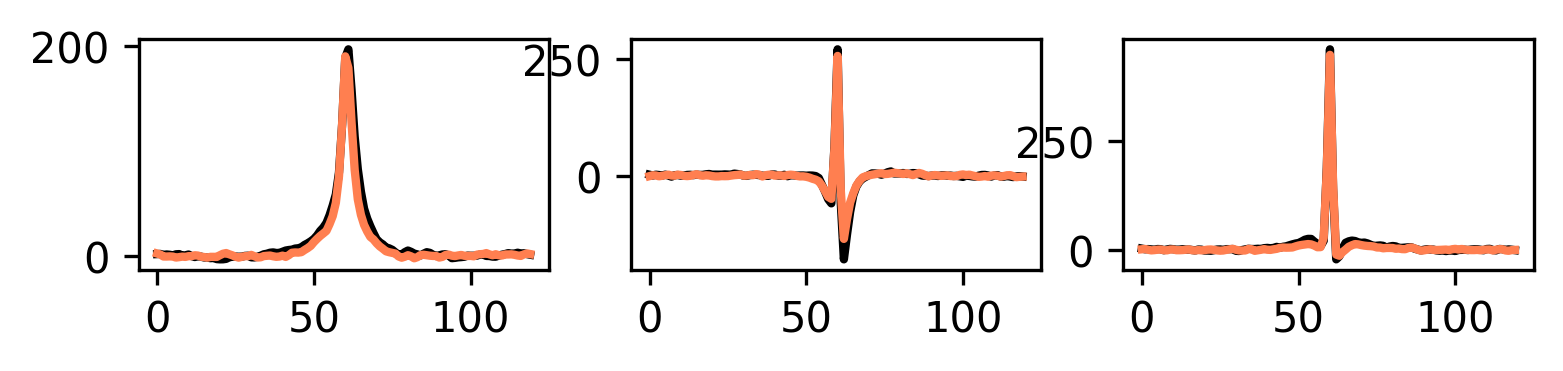

In [256]:
fig, axs=plt.subplots(1,3,figsize=(6,1), dpi=300)
axs = axs.ravel()

axs[0].plot(np.nanmean(PreDOI_dHead_gazeL,axis=0),linewidth = 2, label='Head',color = 'black')
axs[0].plot(np.nanmean(PostDOI_dHead_gazeL,axis=0),linewidth = 2, label='Head',color = 'coral')

axs[1].plot(np.nanmean(PreDOI_dEye_gazeL,axis=0),linewidth = 2, label='Head',color = 'black')
axs[1].plot(np.nanmean(PostDOI_dEye_gazeL,axis=0),linewidth = 2, label='Head',color = 'coral')

axs[2].plot(np.nanmean(PreDOI_dGaze_gazeL,axis=0),linewidth = 2, label='Head',color = 'black')
axs[2].plot(np.nanmean(PostDOI_dGaze_gazeL,axis=0),linewidth = 2, label='Head',color = 'coral')

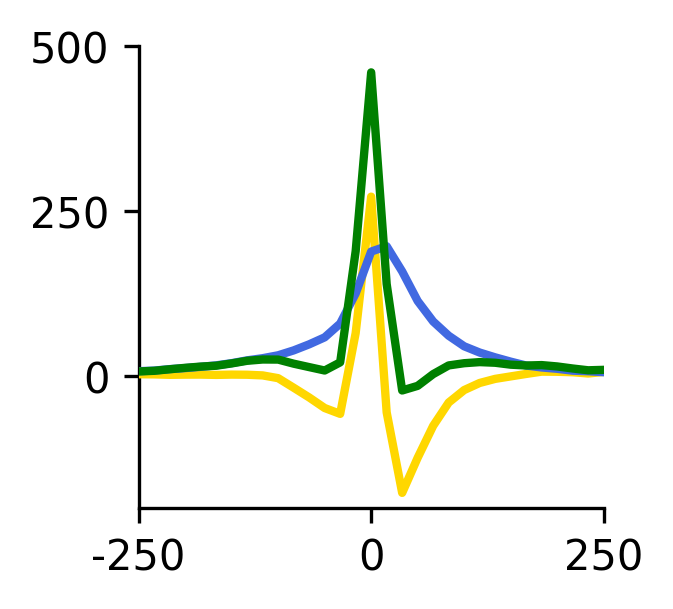

In [439]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.plot(np.nanmean(PreDOI_dHead_gazeL,axis=0),linewidth = 2, label='Head',zorder = 4,color = 'royalblue')
plt.plot(np.nanmean(PreDOI_dEye_gazeL,axis=0),linewidth = 2, label='Eye',zorder = 3,color= 'gold')
plt.plot(np.nanmean(PreDOI_dGaze_gazeL,axis=0),linewidth = 2, label='Gaze',zorder = 5,color = 'green')

plt.xlim(45,75)
plt.ylim(-200,500)
plt.yticks(ticks = [0,250,500])
plt.xticks(ticks = [45,60,75],labels=[-250,0,250])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PreDOI_dHead_dEye_dGaze_4Gazes.eps'),dpi=300)


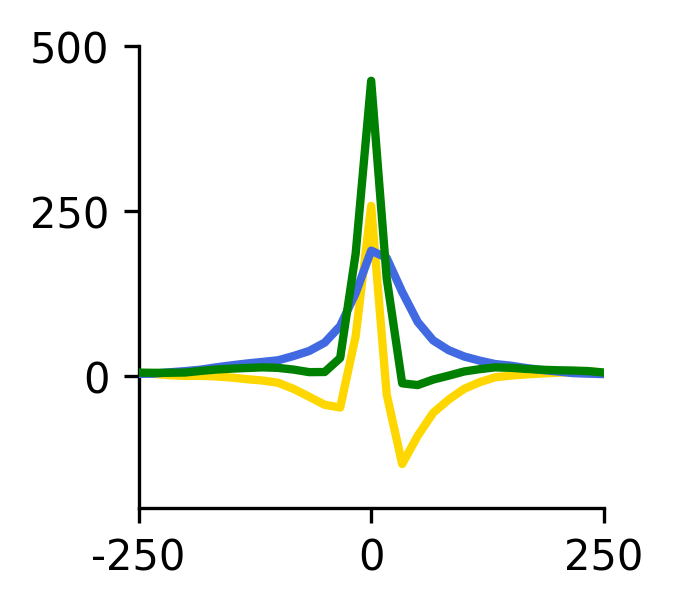

In [449]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.plot(np.nanmean(PostDOI_dHead_gazeL,axis=0),linewidth = 2, label='Head',zorder = 4,color = 'royalblue')
plt.plot(np.nanmean(PostDOI_dEye_gazeL,axis=0),linewidth = 2, label='Eye',zorder = 3,color = 'gold')
plt.plot(np.nanmean(PostDOI_dGaze_gazeL,axis=0),linewidth = 2, label='Gaze',zorder = 5,color = 'green')

plt.xlim(45,75)
plt.ylim(-200,500)
plt.yticks(ticks = [0,250,500])
plt.xticks(ticks = [45,60,75],labels=[-250,0,250])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PostDOI_dHead_dEye_dGaze_4Gazes.eps'),dpi=300)





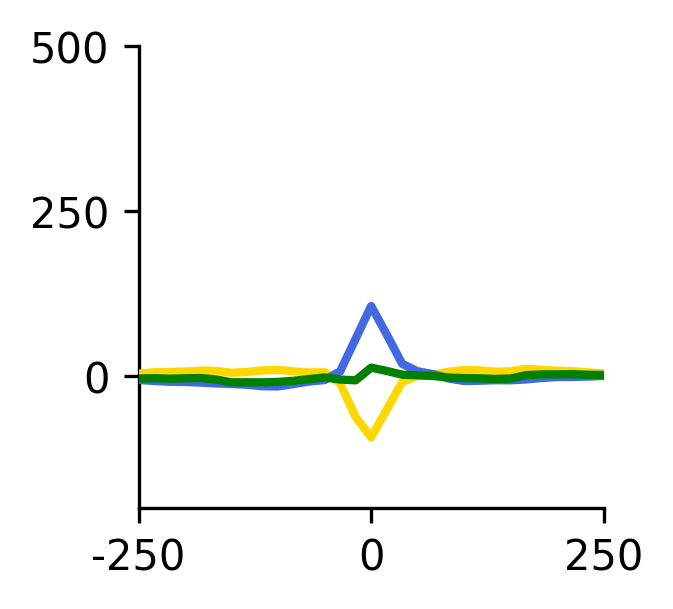

In [448]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.plot(np.nanmean(PreDOI_dHead_compL,axis=0),linewidth = 2, label='Head',zorder = 4,color = 'royalblue')
plt.plot(np.nanmean(PreDOI_dEye_compL,axis=0),linewidth = 2, label='Eye',zorder = 3,color = 'gold')
plt.plot(np.nanmean(PreDOI_dGaze_compL,axis=0),linewidth = 2, label='Gaze',zorder = 5,color= 'green')

plt.xlim(45,75)
plt.ylim(-200,500)
plt.yticks(ticks = [0,250,500])
plt.xticks(ticks = [45,60,75],labels=[-250,0,250])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PreDOI_dHead_dEye_dGaze_4Compensatory.eps'),dpi=300)







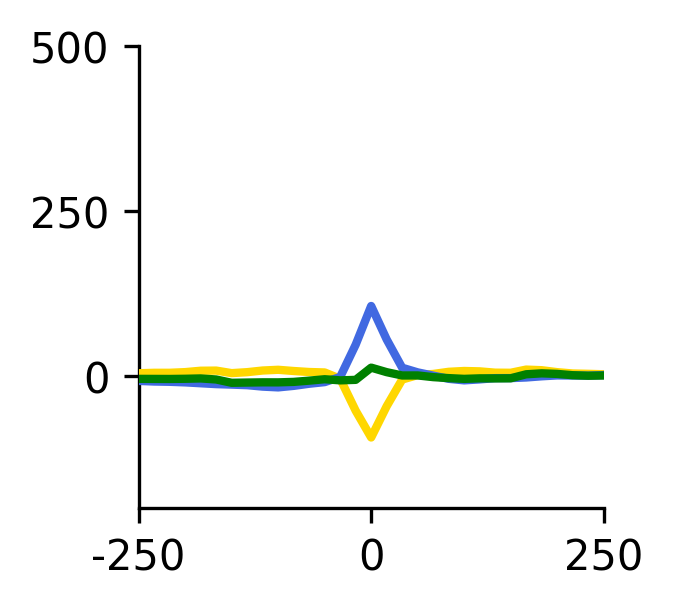

In [447]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.plot(np.nanmean(PostDOI_dHead_compL,axis=0),linewidth = 2, label='Head',zorder = 4,color = 'royalblue')
plt.plot(np.nanmean(PostDOI_dEye_compL,axis=0),linewidth = 2, label='Eye',zorder = 3,color = 'gold')
plt.plot(np.nanmean(PostDOI_dGaze_compL,axis=0),linewidth = 2, label='Gaze',zorder = 5,color = 'green')

plt.xlim(45,75)
plt.ylim(-200,500)
plt.yticks(ticks = [0,250,500])
plt.xticks(ticks = [45,60,75],labels=[-250,0,250])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'PostDOI_dHead_dEye_dGaze_4Compensatory.eps'),dpi=300)







In [7]:
PreDOI_dHead_gazes = (np.concatenate((PreDOI_dHead_gazeL,PreDOI_dHead_gazeR)))
PreDOI_dHead_comps = (np.concatenate((PreDOI_dHead_compL,PreDOI_dHead_compR)))

PreDOI_dEye_gazes = (np.concatenate((PreDOI_dEye_gazeL,PreDOI_dEye_gazeR)))
PreDOI_dEye_comps = (np.concatenate((PreDOI_dEye_compL,PreDOI_dEye_compR)))

PreDOI_dGaze_gazes = (np.concatenate((PreDOI_dGaze_gazeL,PreDOI_dGaze_gazeR)))
PreDOI_dGaze_comps = (np.concatenate((PreDOI_dGaze_compL,PreDOI_dGaze_compR)))

####
PostDOI_dHead_gazes = (np.concatenate((PostDOI_dHead_gazeL,PostDOI_dHead_gazeR)))
PostDOI_dHead_comps = (np.concatenate((PostDOI_dHead_compL,PostDOI_dHead_compR)))

PostDOI_dEye_gazes = (np.concatenate((PostDOI_dEye_gazeL,PostDOI_dEye_gazeR)))
PostDOI_dEye_comps = (np.concatenate((PostDOI_dEye_compL,PostDOI_dEye_compR)))

PostDOI_dGaze_gazes = (np.concatenate((PostDOI_dGaze_gazeL,PostDOI_dGaze_gazeR)))
PostDOI_dGaze_comps = (np.concatenate((PostDOI_dGaze_compL,PostDOI_dGaze_compR)))

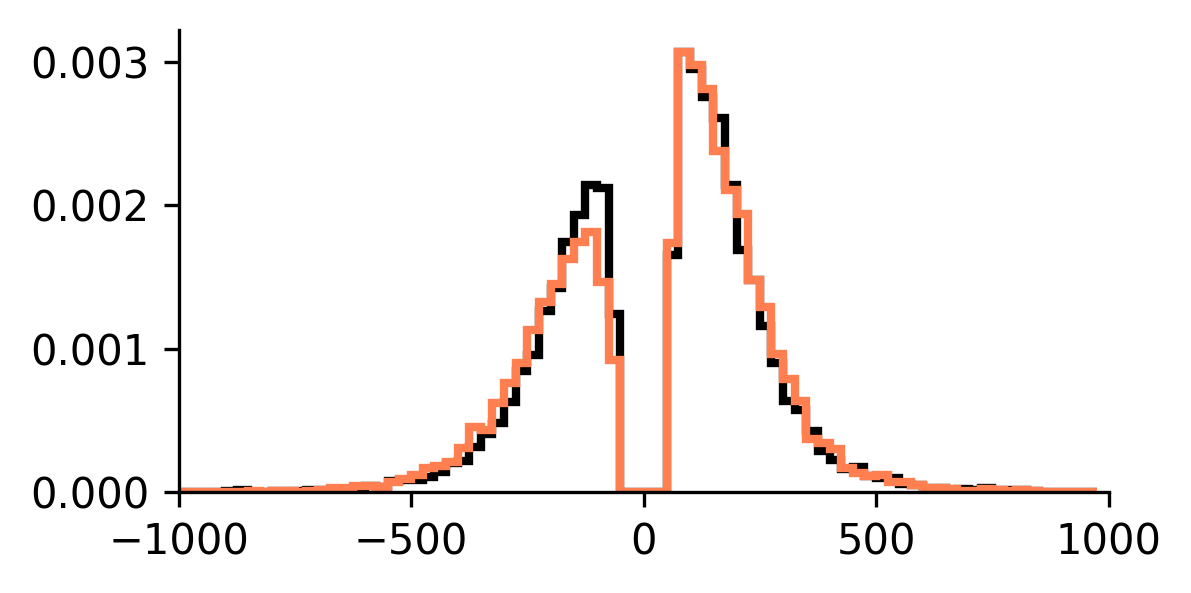

In [77]:
bins= np.arange(-1000,1000,25)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.hist(PreDOI_dHead_gazes[:,60],bins,histtype='step',density=True,color = 'black',linewidth = 2)
plt.hist(PostDOI_dHead_gazes[:,60],bins,histtype='step',density=True,color = 'coral',linewidth = 2)
plt.xlim(-1000,1000)
plt.xticks(ticks = [-1000,-500,0,500,1000])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)


fig.savefig(os.path.join(figpath,'PrePost_dHead_max_amplitude_during gazeshifts.eps'),dpi=300)


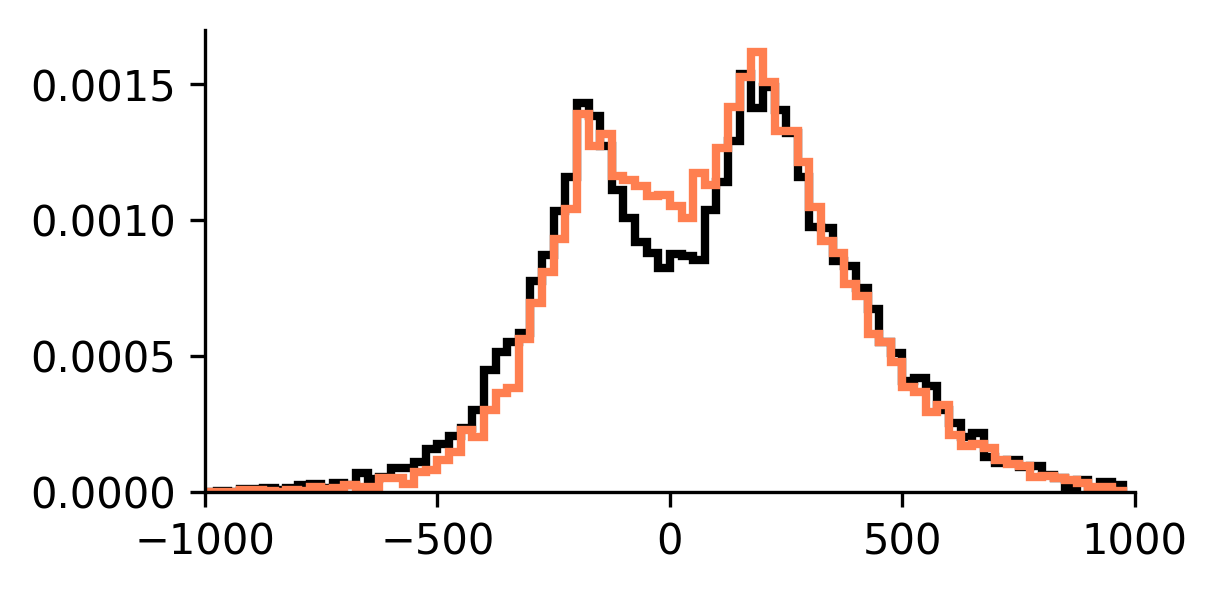

In [78]:
bins= np.arange(-1000,1000,25)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.hist(PreDOI_dEye_gazes[:,60],bins,histtype='step',density=True,color = 'black',linewidth = 2)
plt.hist(PostDOI_dEye_gazes[:,60],bins,histtype='step',density=True,color = 'coral',linewidth = 2)
plt.xlim(-1000,1000)
plt.xticks(ticks = [-1000,-500,0,500,1000])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PrePost_dEye_max_amplitude_during gazeshifts.eps'),dpi=300)

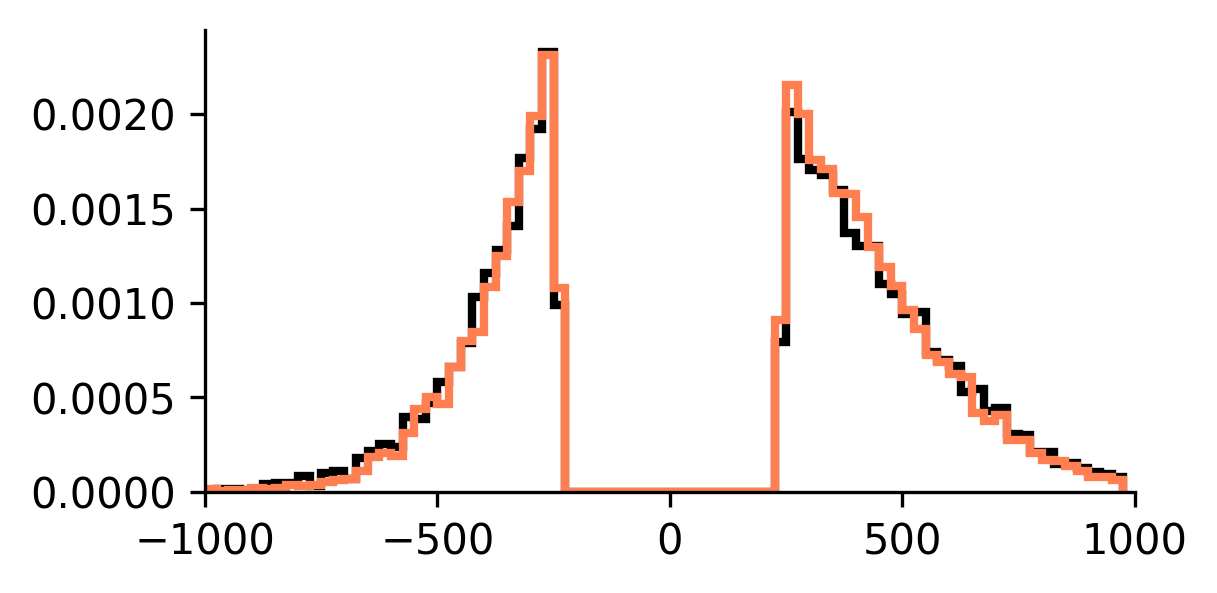

In [79]:
bins= np.arange(-1000,1000,25)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.hist(PreDOI_dGaze_gazes[:,60],bins,histtype='step',density=True,color = 'black',linewidth = 2)
plt.hist(PostDOI_dGaze_gazes[:,60],bins,histtype='step',density=True,color = 'coral',linewidth = 2)
plt.xlim(-1000,1000)
plt.xticks(ticks = [-1000,-500,0,500,1000])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PrePost_dGaze_max_amplitude_during gazeshifts.eps'),dpi=300)

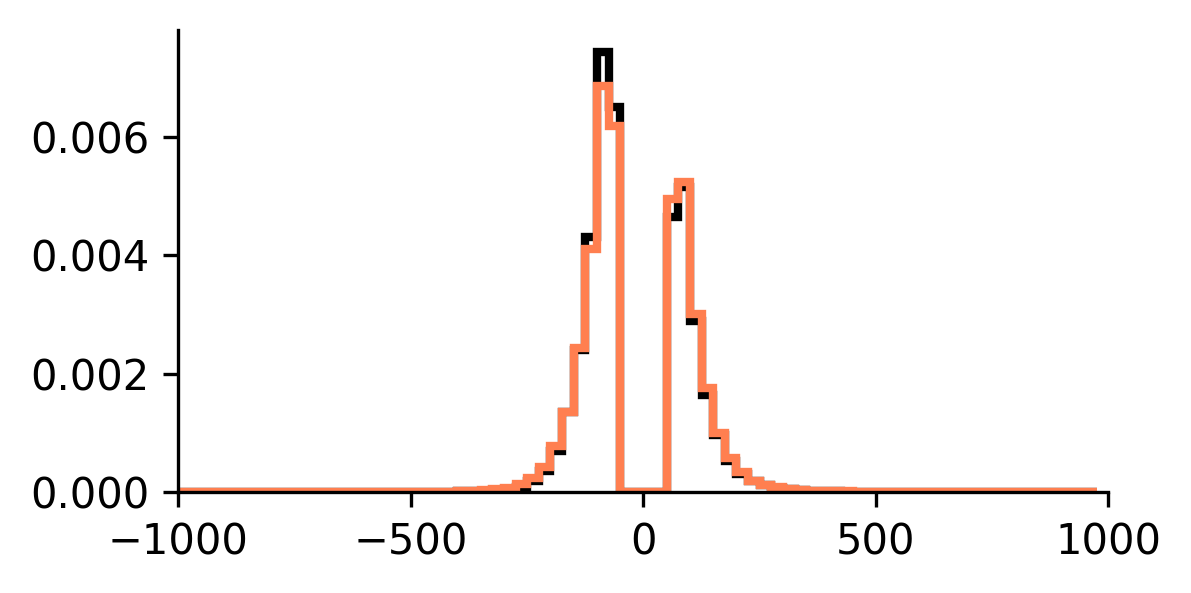

In [80]:
bins= np.arange(-1000,1000,25)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.hist(PreDOI_dHead_comps[:,60],bins,histtype='step',density=True,color = 'black',linewidth = 2)
plt.hist(PostDOI_dHead_comps[:,60],bins,histtype='step',density=True,color = 'coral',linewidth = 2)
plt.xlim(-1000,1000)
plt.xticks(ticks = [-1000,-500,0,500,1000])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PrePost_dHead_max_amplitude_during comps.eps'),dpi=300)

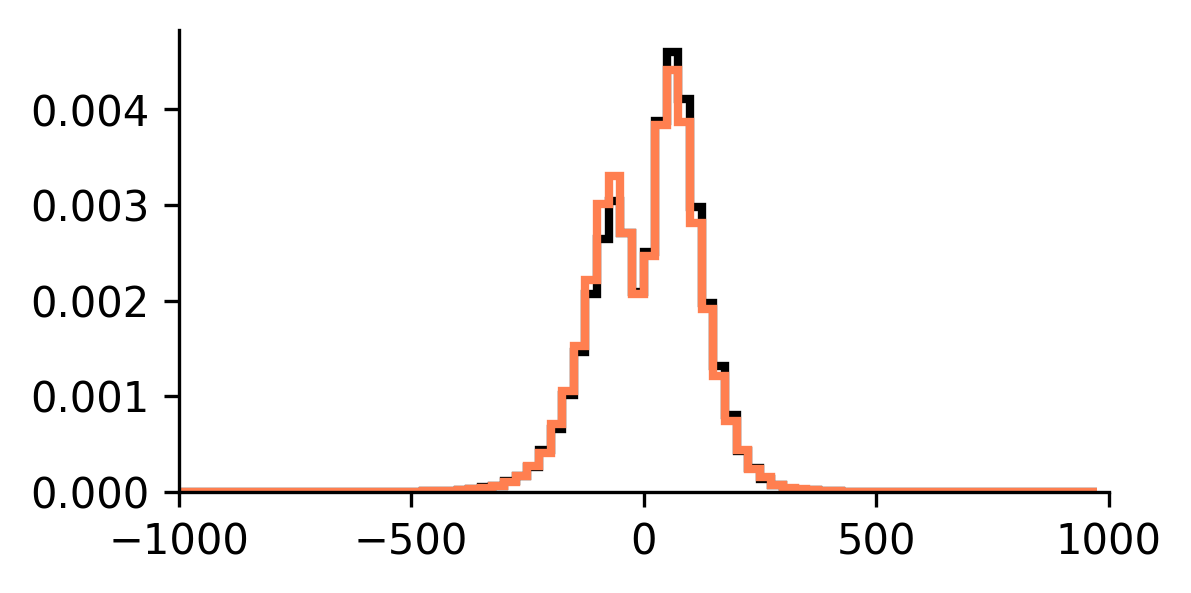

In [81]:
bins= np.arange(-1000,1000,25)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.hist(PreDOI_dEye_comps[:,60],bins,histtype='step',density=True,color = 'black',linewidth = 2)
plt.hist(PostDOI_dEye_comps[:,60],bins,histtype='step',density=True,color = 'coral',linewidth = 2)
plt.xlim(-1000,1000)
plt.xticks(ticks = [-1000,-500,0,500,1000])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PrePost_dEye_max_amplitude_during comps.eps'),dpi=300)

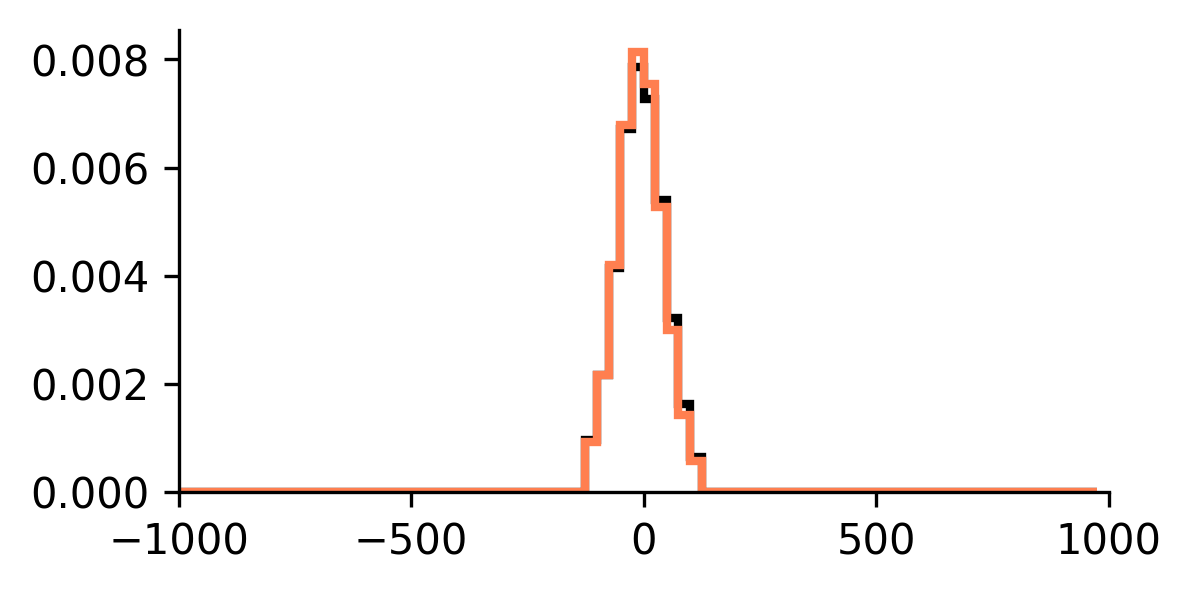

In [82]:
bins= np.arange(-1000,1000,25)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.hist(PreDOI_dGaze_comps[:,60],bins,histtype='step',density=True,color = 'black',linewidth = 2)
plt.hist(PostDOI_dGaze_comps[:,60],bins,histtype='step',density=True,color = 'coral',linewidth = 2)
plt.xlim(-1000,1000)
plt.xticks(ticks = [-1000,-500,0,500,1000])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath,'PrePost_dGaze_max_amplitude_during comps.eps'),dpi=300)

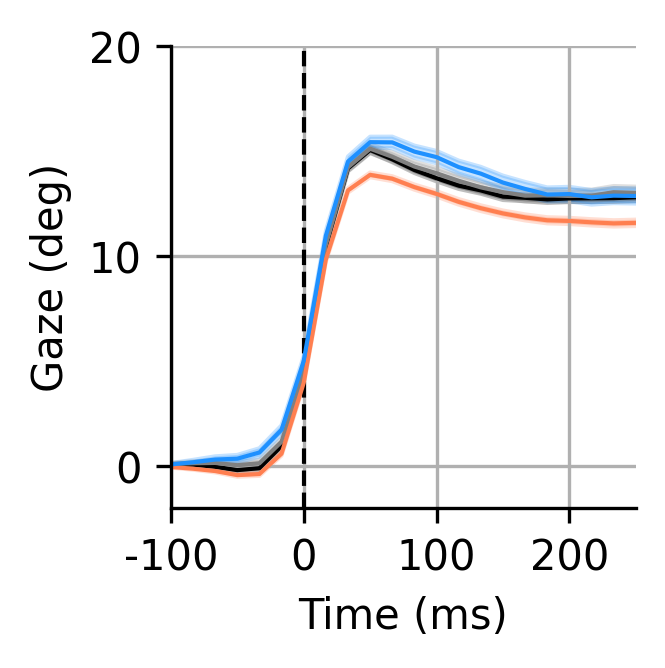

In [192]:
#Plotting average gaze shift magnitude before and after injection

fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.axvline(60,color = 'black', linestyle = '--',linewidth =1)
#plt.axhline(0, color = 'black', linestyle = '--',linewidth =1)
for group_mean, group_std, color, label in zip([np.nanmean(PreDOI_pGaze_gazeL_Norm,axis=0),np.nanmean(PreSaline_pGaze_gazeL_Norm,axis=0), np.nanmean(PostDOI_pGaze_gazeL_Norm,axis=0), np.nanmean(PostSaline_pGaze_gazeL_Norm,axis=0)],
                                                [np.nanstd(PreDOI_pGaze_gazeL_Norm,axis=0)/np.sqrt(len(PreDOI_pGaze_gazeL_Norm)),np.nanstd(PreSaline_pGaze_gazeL_Norm,axis=0)/np.sqrt(len(PreSaline_pGaze_gazeL_Norm)),  np.nanstd(PostDOI_pGaze_gazeL_Norm,axis=0)/np.sqrt(len(PostDOI_pGaze_gazeL_Norm)), np.nanstd(PostSaline_pGaze_gazeL_Norm,axis=0)/np.sqrt(len(PostSaline_pGaze_gazeL_Norm))],
                                                ['black','grey','coral', 'dodgerblue',],
                                                ['Pre-DOI','Pre-Saline','DOI', 'Saline',]):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xlim(54,75)
plt.xticks(ticks= [54,60,66,72],labels = [-100,0,100,200])

plt.ylim(-2,20)
plt.yticks(ticks= [0,10,20])
plt.ylabel('Gaze (deg)')
plt.xlabel('Time (ms)')
plt.grid()

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

plt.gca().set_rasterized(True)

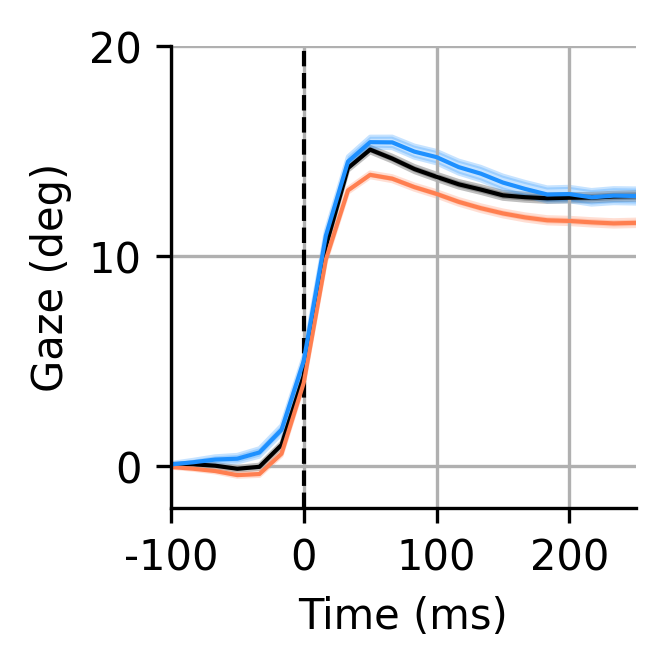

In [196]:
#Plotting average gaze shift magnitude before and after injection

fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.axvline(60,color = 'black', linestyle = '--',linewidth =1)
#plt.axhline(0, color = 'black', linestyle = '--',linewidth =1)
for group_mean, group_std, color, label in zip([np.nanmean(PreDrug_pGaze_gazeL_norm,axis=0), np.nanmean(PostDOI_pGaze_gazeL_Norm,axis=0), np.nanmean(PostSaline_pGaze_gazeL_Norm,axis=0)],
                                                [np.nanstd(PreDrug_pGaze_gazeL_norm,axis=0)/np.sqrt(len(PreDOI_pGaze_gazeL_Norm)), np.nanstd(PostDOI_pGaze_gazeL_Norm,axis=0)/np.sqrt(len(PostDOI_pGaze_gazeL_Norm)), np.nanstd(PostSaline_pGaze_gazeL_Norm,axis=0)/np.sqrt(len(PostSaline_pGaze_gazeL_Norm))],
                                                ['black','coral', 'dodgerblue',],
                                                ['Pre-Injection','DOI', 'Saline',]):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xlim(54,75)
plt.xticks(ticks= [54,60,66,72],labels = [-100,0,100,200])

plt.ylim(-2,20)
plt.yticks(ticks= [0,10,20])
plt.ylabel('Gaze (deg)')
plt.xlabel('Time (ms)')
plt.grid()

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

plt.gca().set_rasterized(True)

fig.savefig(os.path.join(figpath,'E - AverageSEM_GazeL_GazePostition_PrePostInjection.eps'),dpi=300)

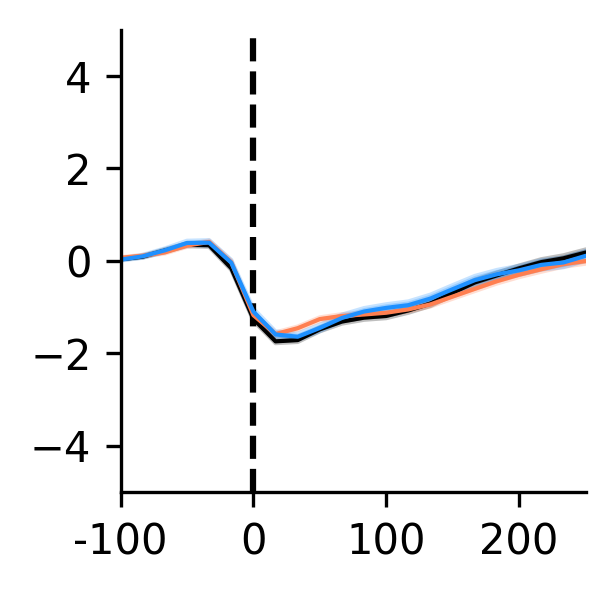

In [17]:

fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.axvline(60,color = 'black', linestyle = '--')
for group_mean, group_std, color, label in zip([np.nanmean(PreDOI_pGaze_compR_Norm,axis=0), np.nanmean(PostDOI_pGaze_compR_Norm,axis=0), np.nanmean(PreSaline_pGaze_compR_Norm,axis=0), np.nanmean(PostSaline_pGaze_compR_Norm,axis=0)],
                                                [np.nanstd(PreDOI_pGaze_compR_Norm,axis=0)/np.sqrt(len(PreDOI_pGaze_compR_Norm)), np.nanstd(PostDOI_pGaze_compR_Norm,axis=0)/np.sqrt(len(PostDOI_pGaze_compR_Norm)), np.nanstd(PreSaline_pGaze_compR_Norm,axis=0)/np.sqrt(len(PreSaline_pGaze_compR_Norm)), np.nanstd(PostSaline_pGaze_compR_Norm,axis=0)/np.sqrt(len(PostSaline_pGaze_compR_Norm))],
                                                ['black','coral', 'dodgerblue'],
                                                ['Pre-Drug','Post-DOI', 'Post-Saline']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xlim(54,75)
plt.xticks(ticks= [54,60,66,72],labels = [-100,0,100,200])

plt.ylim(-5,5)
#plt.yticks(ticks= [0,10,20],labels = [0,10,20])

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

plt.gca().set_rasterized(True)
#fig.savefig(os.path.join(figpath,'AverageSEM_CompensatoryL_GazePostition_PrePostInjection.png'),dpi=300)
#fig.savefig(os.path.join(figpath,'AverageSEM_CompensatoryL_GazePostition_PrePostInjection.eps'),dpi=300)

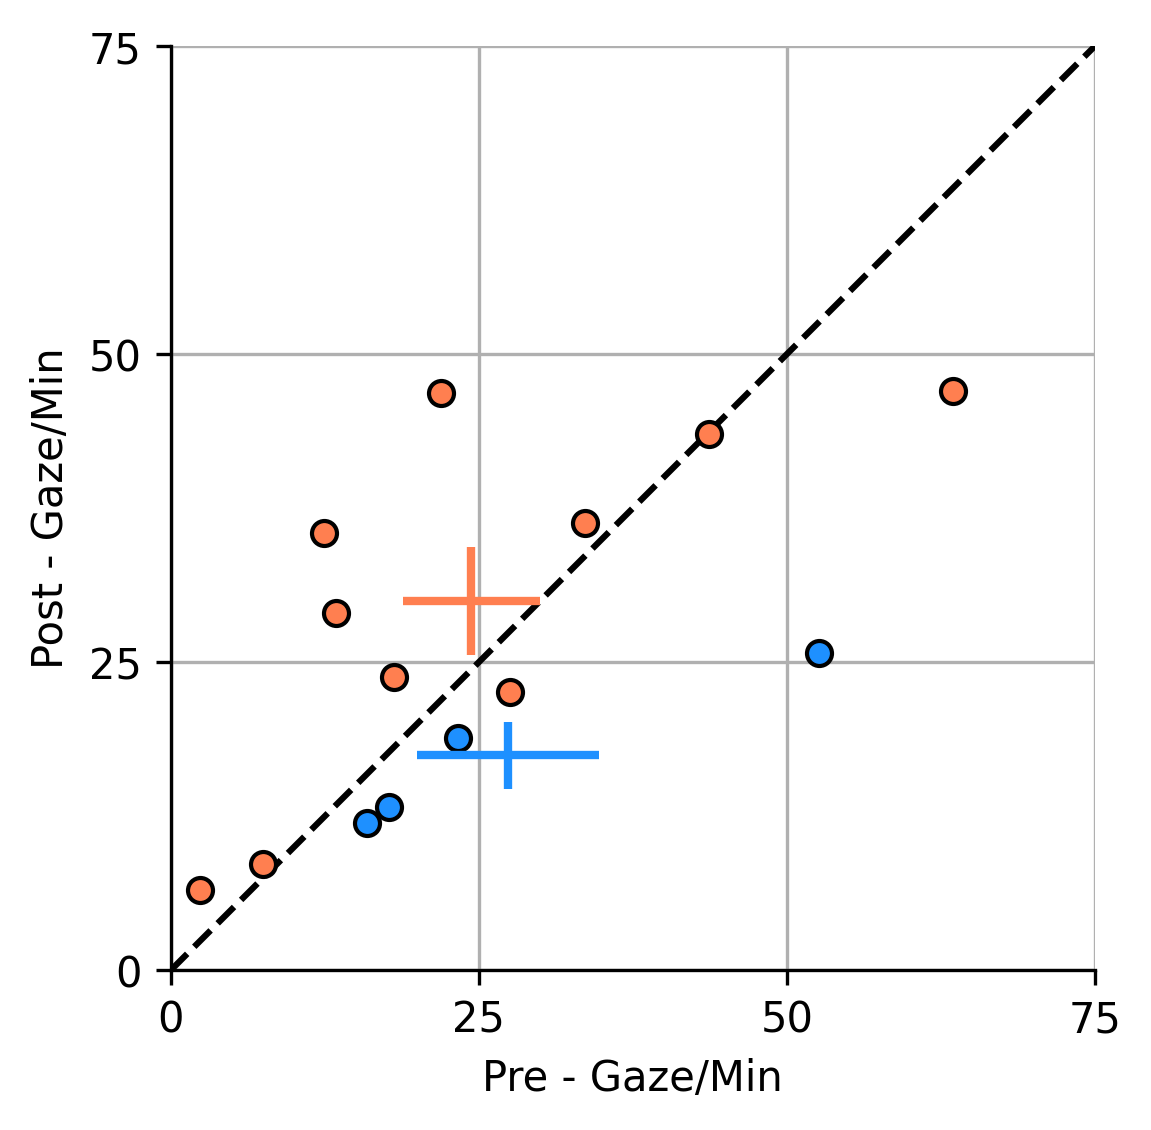

In [9]:
fig, axs=plt.subplots(1,1,figsize=(4,4), dpi=300)

plt.scatter(Pre_GazePerMin[0:10],Post_GazePerMin[0:10],color = 'coral',edgecolor = 'black',zorder = 7)
#plt.scatter(Pre_GazePerMin[zz],Post_GazePerMin[zz],color = 'black',zorder = 8)
plt.scatter(Pre_GazePerMin[10:],Post_GazePerMin[10:],color = 'dodgerblue',edgecolor = 'black',zorder = 7)
plt.plot([0,75],[0,75],linestyle='--',color = 'black')

plt.errorbar(x = np.nanmean(Pre_GazePerMin[0:10]),y = np.nanmean(Post_GazePerMin[0:10]),xerr = np.nanstd(Pre_GazePerMin[0:10])/np.sqrt(len(Pre_GazePerMin[0:10])),yerr = np.nanstd(Post_GazePerMin[0:10])/np.sqrt(len(Post_GazePerMin[0:10])),color= 'coral',linewidth=2,zorder = 8)
plt.errorbar(x = np.nanmean(Pre_GazePerMin[10:]),y = np.nanmean(Post_GazePerMin[10:]),xerr = np.nanstd(Pre_GazePerMin[10:])/np.sqrt(len(Pre_GazePerMin[10:])),yerr = np.nanstd(Post_GazePerMin[10:])/np.sqrt(len(Post_GazePerMin[10:])),color= 'dodgerblue',linewidth=2,zorder = 8)

plt.xlabel('Pre - Gaze/Min')
plt.ylabel('Post - Gaze/Min')

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

plt.xlim(0,75)
plt.ylim(0,75)
plt.xticks(np.arange(0,100,25))
plt.yticks(np.arange(0,100,25))
plt.grid(zorder = 3)
plt.gca().set_rasterized(True)
plt.gca().set_aspect('equal', 'box')
#fig.savefig(os.path.join(figpath,'F - GazePerMin_PrePost.eps'),dpi=300)



2.1243266348159193
0.027554452780550003


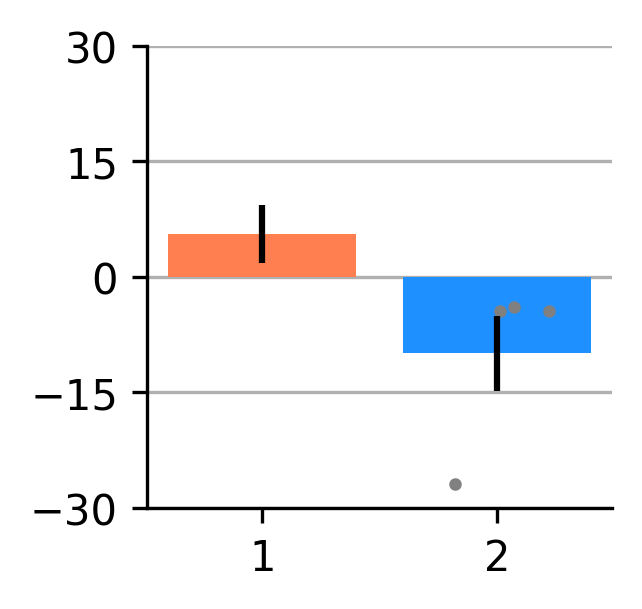

In [32]:
#Plotting change in number of gaze shifts bar plot
GazePerMin_Change = Post_GazePerMin-Pre_GazePerMin
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

DOI_GazePerMin_Change = GazePerMin_Change[0:10]



plt.bar(1,np.nanmean(GazePerMin_Change[0:10]),color = 'coral',zorder =5)
#plt.scatter(jitter(0,len(NotTheExampleMouse),maxdist=0.25), GazePerMin_Change[NotTheExampleMouse],color='grey',zorder = 6,s=4)
#plt.scatter(jitter(0,1,maxdist=0.25), GazePerMin_Change[zz],color='black',zorder = 6,s=4)
plt.errorbar(1,np.nanmean(GazePerMin_Change[0:10]),np.nanstd(GazePerMin_Change[0:10])/np.sqrt(10),color = 'black',zorder =6)


plt.bar(2,np.nanmean(GazePerMin_Change[10:]),color = 'dodgerblue',zorder =5)
plt.scatter(jitter(1,len(GazePerMin_Change[10:]),maxdist=0.25), GazePerMin_Change[10:],color='grey',zorder = 6,s=4)
plt.errorbar(2,np.nanmean(GazePerMin_Change[10:]),np.nanstd(GazePerMin_Change[10:])/np.sqrt(4),color = 'black',zorder =6)
plt.grid(axis= 'y',zorder = 4)
#plt.ylim(-1,1)
plt.yticks(ticks=[-30,-15,0,15,30])
plt.xticks(ticks=[1,2])
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
#fig.savefig(os.path.join(figpath,'F - GazePerMin_InjectionEffect_BarPlot.eps'),dpi=300)


t_stat, p_value = stats.ttest_ind(GazePerMin_Change[0:10],GazePerMin_Change[10:],alternative='greater')
print(t_stat)
print(p_value)




([<matplotlib.axis.XTick at 0x1ca0113b670>,
 [Text(1.5, 0, '1.5'), Text(4.5, 0, '4.5')])

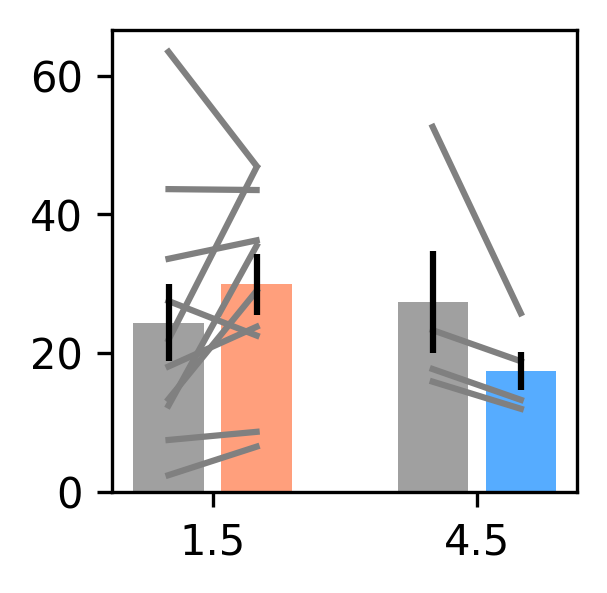

In [13]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.bar(1,np.nanmean(Pre_GazePerMin[0:10]),color='grey',alpha=.75)
plt.errorbar(1,np.nanmean(Pre_GazePerMin[0:10]),np.nanstd(Pre_GazePerMin[0:10])/np.sqrt(10),color = 'black',zorder =6)
#plt.scatter(jitter(0,10),Pre_GazePerMin[0:10],color = 'grey')

plt.bar(2,np.nanmean(Post_GazePerMin[0:10]),color='coral',alpha=.75)
plt.errorbar(2,np.nanmean(Post_GazePerMin[0:10]),np.nanstd(Post_GazePerMin[0:10])/np.sqrt(10),color = 'black',zorder =6)
#plt.scatter(jitter(1,10),Post_GazePerMin[0:10],color = 'grey')

plt.plot([np.ones(10),np.ones(10)*2],[Pre_GazePerMin[0:10],Post_GazePerMin[0:10]],color= 'grey')

plt.bar(4,np.nanmean(Pre_GazePerMin[10:]),color='grey',alpha=.75)
plt.errorbar(4,np.nanmean(Pre_GazePerMin[10:]),np.nanstd(Pre_GazePerMin[10:])/np.sqrt(4),color = 'black',zorder =6)
#plt.scatter(jitter(2,4),Pre_GazePerMin[10:],color = 'grey')

plt.bar(5,np.nanmean(Post_GazePerMin[10:]),color='dodgerblue',alpha=.75)
plt.errorbar(5,np.nanmean(Post_GazePerMin[10:]),np.nanstd(Post_GazePerMin[10:])/np.sqrt(4),color = 'black',zorder =6)
#plt.scatter(jitter(3,4),Post_GazePerMin[10:],color = 'grey')

plt.plot([np.ones(4)*4,np.ones(4)*5],[Pre_GazePerMin[10:],Post_GazePerMin[10:]],color= 'grey')

plt.xticks(ticks =[1.5,4.5])
#fig.savefig(os.path.join(figpath,'GazePerMinPrePostInjectionBarPlot'),dpi=300)

In [26]:
print(np.nanmean(GazePerMin_Change[0:10]))
print(np.nanstd(GazePerMin_Change[0:10])/np.sqrt(10))

print(np.nanmean(GazePerMin_Change[10:]))
print(np.nanstd(GazePerMin_Change[10:])/np.sqrt(4))

0.1669123516655348
0.06992347987589922
-0.18310018909500408
0.04666884605419036


In [19]:
print(np.nanmean(Pre_GazePerMin[0:10]))
print(np.nanstd(Pre_GazePerMin[0:10])/np.sqrt(10))

print(np.nanmean(Post_GazePerMin[0:10]))
print(np.nanstd(Post_GazePerMin[0:10])/np.sqrt(10))

24.393856934558976
8.761195642534808
29.955754658555783
6.938621856425503


In [21]:
print(np.nanmean(Pre_GazePerMin[10:]))
print(np.nanstd(Pre_GazePerMin[10:])/np.sqrt(4))

print(np.nanmean(Post_GazePerMin[10:]))
print(np.nanstd(Post_GazePerMin[10:])/np.sqrt(4))

27.37804714394673
7.414239160535415
17.457673763062495
2.7197448098000643


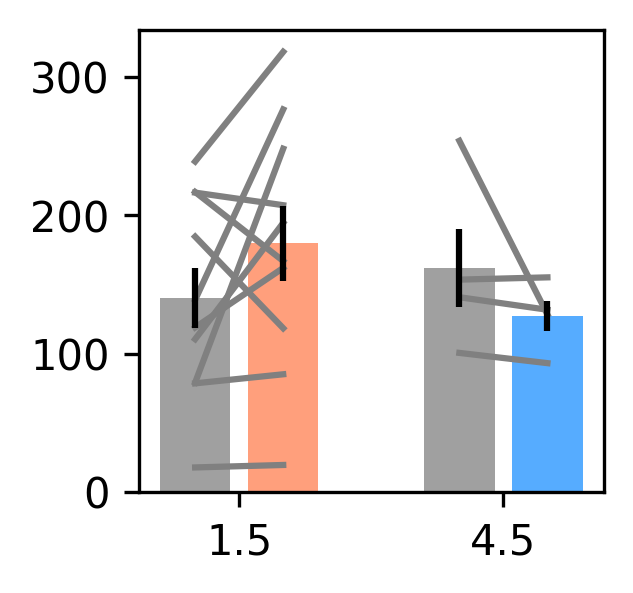

In [480]:
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
plt.bar(1,np.nanmean(Pre_CompPerMin[0:10]),color='grey',alpha=.75)
plt.errorbar(1,np.nanmean(Pre_CompPerMin[0:10]),np.nanstd(Pre_CompPerMin[0:10])/np.sqrt(10),color = 'black',zorder =6)
#plt.scatter(jitter(0,10),Pre_CompPerMin[0:10],color = 'grey')

plt.bar(2,np.nanmean(Post_CompPerMin[0:10]),color='coral',alpha=.75)
plt.errorbar(2,np.nanmean(Post_CompPerMin[0:10]),np.nanstd(Post_CompPerMin[0:10])/np.sqrt(10),color = 'black',zorder =6)
#plt.scatter(jitter(1,10),Post_CompPerMin[0:10],color = 'grey')

plt.plot([np.ones(10),np.ones(10)*2],[Pre_CompPerMin[0:10],Post_CompPerMin[0:10]],color= 'grey')

plt.bar(4,np.nanmean(Pre_CompPerMin[10:]),color='grey',alpha=.75)
plt.errorbar(4,np.nanmean(Pre_CompPerMin[10:]),np.nanstd(Pre_CompPerMin[10:])/np.sqrt(4),color = 'black',zorder =6)
#plt.scatter(jitter(2,4),Pre_CompPerMin[10:],color = 'grey')

plt.bar(5,np.nanmean(Post_CompPerMin[10:]),color='dodgerblue',alpha=.75)
plt.errorbar(5,np.nanmean(Post_CompPerMin[10:]),np.nanstd(Post_CompPerMin[10:])/np.sqrt(4),color = 'black',zorder =6)
#plt.scatter(jitter(3,4),Post_CompPerMin[10:],color = 'grey')

plt.plot([np.ones(4)*4,np.ones(4)*5],[Pre_CompPerMin[10:],Post_CompPerMin[10:]],color= 'grey')

plt.xticks(ticks =[1.5,4.5])
fig.savefig(os.path.join(figpath,'CompPerMinPrePostInjectionBarPlot'),dpi=300)


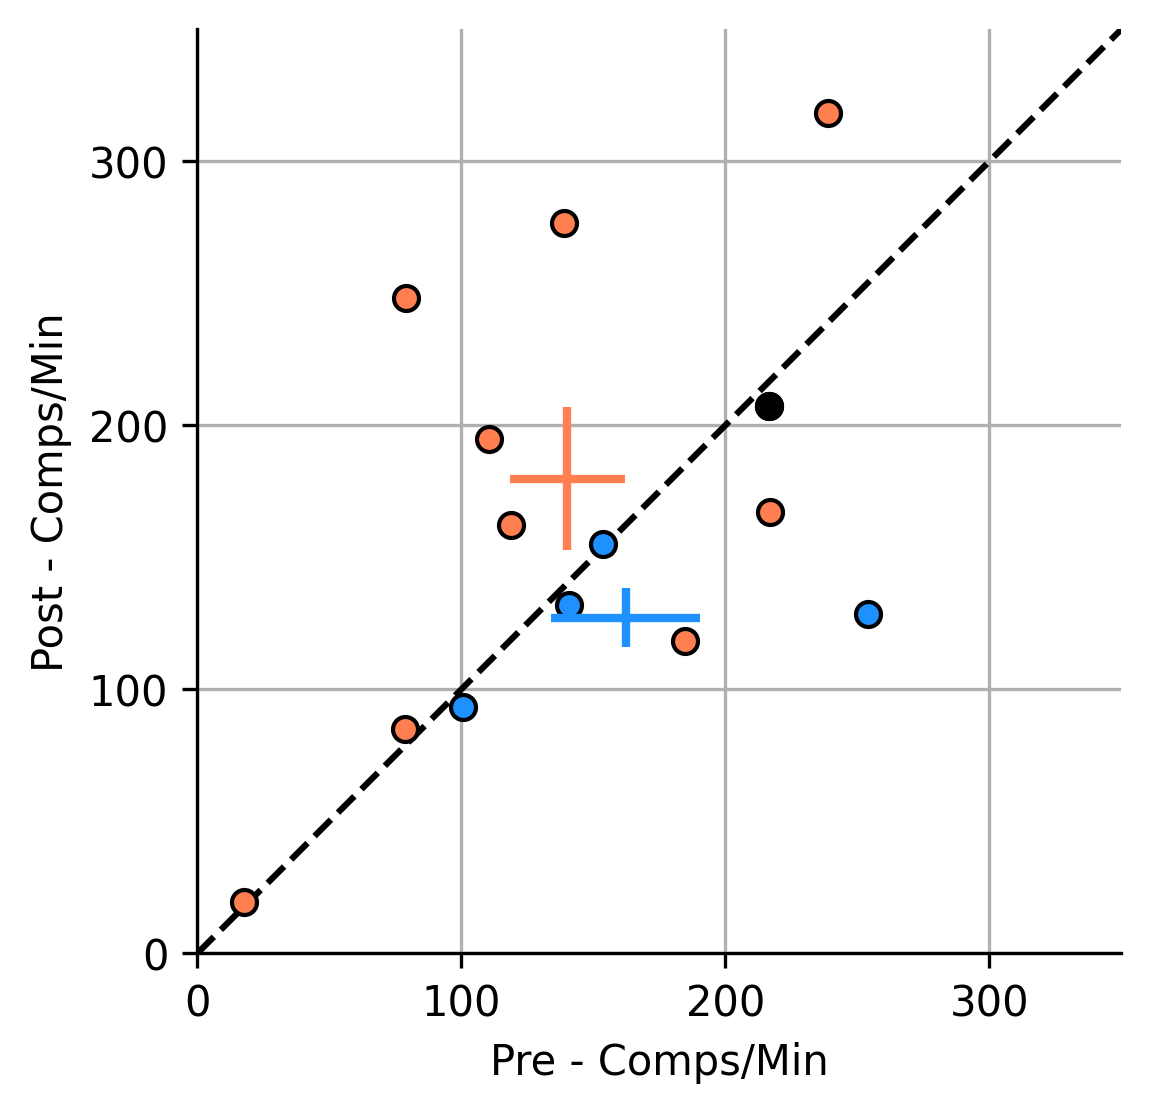

In [431]:
fig, axs=plt.subplots(1,1,figsize=(4,4), dpi=300)

plt.scatter(Pre_CompPerMin[0:10],Post_CompPerMin[0:10],color = 'coral',edgecolor = 'black',zorder = 7)
plt.scatter(Pre_CompPerMin[zz],Post_CompPerMin[zz],color = 'black',zorder = 8)
plt.scatter(Pre_CompPerMin[10:],Post_CompPerMin[10:],color = 'dodgerblue',edgecolor = 'black',zorder = 7)
plt.plot([0,350],[0,350],linestyle='--',color = 'black')

plt.errorbar(x = np.nanmean(Pre_CompPerMin[0:10]),y = np.nanmean(Post_CompPerMin[0:10]),xerr = np.nanstd(Pre_CompPerMin[0:10])/np.sqrt(len(Pre_CompPerMin[0:10])),yerr = np.nanstd(Post_CompPerMin[0:10])/np.sqrt(len(Post_CompPerMin[0:10])),color= 'coral',linewidth=2,zorder = 8)
plt.errorbar(x = np.nanmean(Pre_CompPerMin[10:]),y = np.nanmean(Post_CompPerMin[10:]),xerr = np.nanstd(Pre_CompPerMin[10:])/np.sqrt(len(Pre_CompPerMin[10:])),yerr = np.nanstd(Post_CompPerMin[10:])/np.sqrt(len(Post_CompPerMin[10:])),color= 'dodgerblue',linewidth=2,zorder = 8)

plt.xlabel('Pre - Comps/Min')
plt.ylabel('Post - Comps/Min')

plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

plt.xlim(0,350)
plt.ylim(0,350)
plt.xticks(np.arange(0,350,100))
plt.yticks(np.arange(0,350,100))
plt.grid(zorder = 3)
plt.gca().set_rasterized(True)
plt.gca().set_aspect('equal', 'box')
fig.savefig(os.path.join(figpath,'F - CompsPerMin_PrePost.eps'),dpi=300)


1.7157421516165405
0.05594464041324241


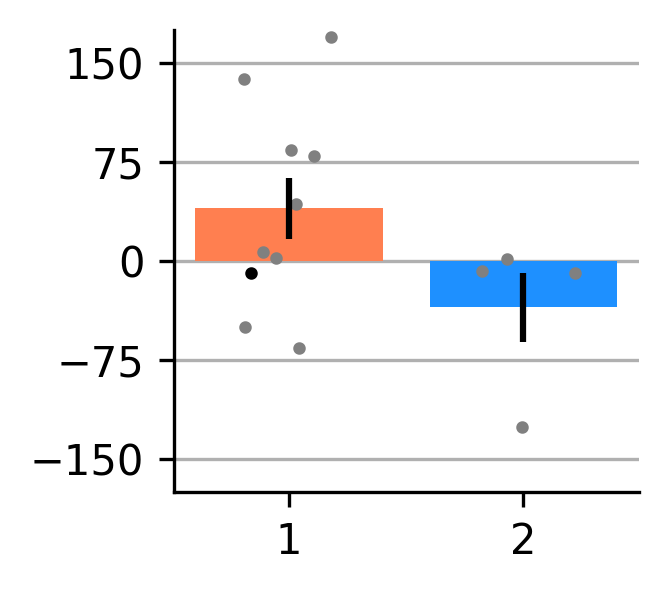

In [494]:
CompPerMin_Change = Post_CompPerMin-Pre_CompPerMin
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)

DOI_CompPerMin_Change = CompPerMin_Change[0:10]



plt.bar(1,np.nanmean(CompPerMin_Change[0:10]),color = 'coral',zorder =5)
plt.scatter(jitter(0,len(NotTheExampleMouse),maxdist=0.25), CompPerMin_Change[NotTheExampleMouse],color='grey',zorder = 6,s=4)
plt.scatter(jitter(0,1,maxdist=0.25), CompPerMin_Change[zz],color='black',zorder = 6,s=4)
plt.errorbar(1,np.nanmean(CompPerMin_Change[0:10]),np.nanstd(CompPerMin_Change[0:10])/np.sqrt(10),color = 'black',zorder =6)


plt.bar(2,np.nanmean(CompPerMin_Change[10:]),color = 'dodgerblue',zorder =5)
plt.scatter(jitter(1,len(CompPerMin_Change[10:]),maxdist=0.25), CompPerMin_Change[10:],color='grey',zorder = 6,s=4)
plt.errorbar(2,np.nanmean(CompPerMin_Change[10:]),np.nanstd(CompPerMin_Change[10:])/np.sqrt(4),color = 'black',zorder =6)
plt.grid(axis= 'y',zorder = 4)
plt.ylim(-175,175)
plt.yticks(ticks=[-150,-75,0,75,150])
plt.xticks(ticks=[1,2])
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath,'F - CompPerMin_InjectionEffect_BarPlot.eps'),dpi=300)


t_stat, p_value = stats.ttest_ind(CompPerMin_Change[0:10],CompPerMin_Change[10:],alternative='greater')
print(t_stat)
print(p_value)
